# Statistical comparison of plasmid detection tools

In [1]:
# --- Required Libraries --------------------------------------
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from scikit_posthocs import posthoc_dunn
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text

warnings.filterwarnings('ignore')


In [2]:
# --- Configuration ------------------------------------------
#METRICS_FILE  = "/rds/projects/e/elhamsak-mbru-amr/results/plasmid_benchmark/validation_metrics/all_metrics.tsv"
METRICS_FILE  = "/rds/projects/e/elhamsak-mbru-amr/results/plasmid_benchmark/validation_metrics/all_metrics.tsv"
OUTPUT_DIR    = "/rds/projects/e/elhamsak-mbru-amr/results/plasmid_benchmark/statistical_analysis"
ALPHA         = 0.05

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'font.family':      'sans-serif',
    'font.size':        10,
    'axes.titlesize':   11,
    'axes.labelsize':   10,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'figure.dpi':       150,
})

# Color palette per tool
TOOL_PALETTE = [
    '#E69F00', '#56B4E9', '#009E73',
    '#F0E442', '#0072B2', '#D55E00',
]


In [3]:
# --- Load data -------------------------------------------------------
df_raw = pd.read_csv(METRICS_FILE, sep='\t', na_values=['NA'])
df_raw = df_raw.dropna(subset=['Tool'])
df_raw.head()


,Tool,Platform,Species,Sample,Ref_Plasmid_Count,Pred_Plasmid_Count,TP,FP,FN,Accuracy,Circular_TP,Circularization_Pct,Sensitivity,Contig_Precision,BP_Precision,F1_Score,Mean_Identity,Mean_Completeness,Contamination_Pct,Size_Category
0,MOB-suite,ONT,ecoli,SRR18592170,2,2,244091,1,72,0.9997,244091,99.9705,0.9997,0.0,1.0000,0.9999,99.5711,99.9705,0.0004,>100kb
1,MOB-suite,ONT,ecoli,SRR19165765,1,1,151634,0,42,0.9997,151634,99.9723,0.9997,0.0,1.0000,0.9999,99.2871,99.9723,0.0000,>100kb
2,MOB-suite,ONT,ecoli,SRR19165770,3,4,237709,7568,93,0.9688,237709,99.9609,0.9996,0.0,0.9691,0.9841,99.3893,99.9609,3.0855,5-10kb
3,MOB-suite,ONT,ecoli,SRR19165771,2,2,173788,0,62,0.9996,173788,99.9643,0.9996,0.0,1.0000,0.9998,98.3853,99.9643,0.0000,10-100kb
4,MOB-suite,ONT,ecoli,SRR19165775,1,2,125559,7997,39,0.9398,125559,99.9689,0.9997,0.0,0.9401,0.9690,99.3780,99.9689,5.9878,>100kb


In [4]:
# --- Exclude plasmid-free / no-alignment rows ----------------------------------------------------
df = df_raw[~((df_raw['Ref_Plasmid_Count'] == 0) & (df_raw['Pred_Plasmid_Count'] == 0))].copy().rename(columns={'BP_Precision': 'Precision'})

# Coerce numeric # CIRCULAR_RECOVERY_RATE
METRICS = [
    'F1_Score', 'Precision', 'Sensitivity', 
    'Mean_Completeness', 'Contamination_Pct', 'Circularization_Pct',
]
for col in METRICS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

TOOLS     = sorted(df['Tool'].unique())
PLATFORMS = ['ONT', 'PacBio']
SPECIES   = sorted(df['Species'].unique())
TOOL_COLORS = dict(zip(TOOLS, TOOL_PALETTE[:len(TOOLS)]))
SIZE_ORDER = ["0-1kb", "1-5kb", "5-10kb", "10-100kb", ">100kb"]
SCALE_0_TO_1_METRICS = ["Accuracy", "F1_Score", "Precision", "Sensitivity"]

print("=" * 60)
print(" Statistical Analysis: Plasmid Detection Benchmarking")
print("=" * 60)
print(f"Tools    : {TOOLS}")
print(f"Samples  : {len(df)} (after excluding plasmid-free rows)")
print(f"Platforms: {PLATFORMS}")
print(f"Species  : {SPECIES}")
print()


 Statistical Analysis: Plasmid Detection Benchmarking
Tools    : ['MOB-suite', 'Plasmer', 'PlasmidEC', 'Plassembler', 'Platon', 'RFPlasmid']
Samples  : 600 (after excluding plasmid-free rows)
Platforms: ['ONT', 'PacBio']
Species  : ['ecoli']



## Statistical Analysis

In [5]:
# --- 1. Descriptive statistics ----------------------------------------------
print("--- 1. Descriptive Statistics -----------------------------------------\n")
desc_rows = []

for tool in TOOLS:
    sub = df[df['Tool'] == tool]
    for metric in METRICS:
        vals = sub[metric].dropna()
        if len(vals) == 0:
            continue
        
        desc_rows.append({
            'Tool': tool,
            'Metric': metric,
            'SampleCount': len(vals),
            'Mean': round(vals.mean(), 2),
            'Median': round(vals.median(), 2),
            'StandardDeviation': round(vals.std(), 2),
            'Min': round(vals.min(), 2),
            'Max': round(vals.max(), 2)
        })

desc_df = pd.DataFrame(desc_rows)

# Save tidy table
desc_df.to_csv(f"{OUTPUT_DIR}/descriptive_statistics.tsv", sep='\t', index=False)

# Pretty terminal display
for metric in METRICS:
    print(f"\n{metric}")
    print("-" * len(metric))
    display_df = (
        desc_df[desc_df['Metric'] == metric]
        [['Tool', 'SampleCount', 'Mean', 'Median', 'StandardDeviation']]
        .sort_values('Median', ascending=False)
    )
    print(display_df.to_string(index=False))

print()


--- 1. Descriptive Statistics -----------------------------------------


F1_Score
--------
       Tool  SampleCount  Mean  Median  StandardDeviation
Plassembler          100  0.94    0.99               0.11
     Platon          100  0.78    0.97               0.30
    Plasmer          100  0.79    0.96               0.28
  MOB-suite          100  0.79    0.96               0.29
  PlasmidEC          100  0.79    0.96               0.28
  RFPlasmid          100  0.79    0.95               0.28

Precision
---------
       Tool  SampleCount  Mean  Median  StandardDeviation
    Plasmer          100  0.81    1.00               0.28
  PlasmidEC          100  0.81    1.00               0.28
     Platon          100  0.80    1.00               0.30
Plassembler          100  0.96    1.00               0.13
  MOB-suite          100  0.80    0.99               0.29
  RFPlasmid          100  0.81    0.99               0.28

Sensitivity
-----------
       Tool  SampleCount  Mean  Median  StandardDe

In [6]:
# --- 2. Normality test (Shapiro-Wilk) ----------------------------------
print("--- 2. Normality Tests (Shapiro-Wilk) ------------------------------------------------")
norm_rows = []
for tool in TOOLS:
    for metric in METRICS:
        vals = df[df['Tool'] == tool][metric].dropna()
        if len(vals) < 3:
            continue
        sample = vals if len(vals) <= 5000 else vals.sample(5000, random_state=42)
        stat, p = stats.shapiro(sample)
        norm_rows.append({'Tool': tool, 'Metric': metric,
                          'W': round(stat, 4), 'p': round(p, 4),
                          'Normal': p > ALPHA})

norm_df = pd.DataFrame(norm_rows)
norm_df.to_csv(f"{OUTPUT_DIR}/normality_tests.tsv", sep='\t', index=False)
print(norm_df.to_string(index=False))
n_nonnormal = (~norm_df['Normal']).sum()
print(f"\n{n_nonnormal}/{len(norm_df)} distributions non-normal → using non-parametric tests.")
print()


--- 2. Normality Tests (Shapiro-Wilk) ------------------------------------------------
       Tool              Metric      W   p  Normal
  MOB-suite            F1_Score 0.7364 0.0   False
  MOB-suite           Precision 0.7055 0.0   False
  MOB-suite         Sensitivity 0.7267 0.0   False
  MOB-suite   Mean_Completeness 0.7267 0.0   False
  MOB-suite   Contamination_Pct 0.6919 0.0   False
  MOB-suite Circularization_Pct 0.7267 0.0   False
    Plasmer            F1_Score 0.7330 0.0   False
    Plasmer           Precision 0.6932 0.0   False
    Plasmer         Sensitivity 0.7218 0.0   False
    Plasmer   Mean_Completeness 0.7218 0.0   False
    Plasmer   Contamination_Pct 0.6932 0.0   False
    Plasmer Circularization_Pct 0.7218 0.0   False
  PlasmidEC            F1_Score 0.7331 0.0   False
  PlasmidEC           Precision 0.6928 0.0   False
  PlasmidEC         Sensitivity 0.7218 0.0   False
  PlasmidEC   Mean_Completeness 0.7218 0.0   False
  PlasmidEC   Contamination_Pct 0.6928 0.0   F

In [7]:
# --- 3.1 Kruskal-Wallis (overall tool comparison) -------------------------
print("--- 3.1 Kruskal-Wallis: Overall Tool Comparison ----------------------")
kw_rows = []
for metric in METRICS:
    groups = [df[df['Tool'] == t][metric].dropna().values for t in TOOLS]
    groups = [g for g in groups if len(g) >= 3]
    if len(groups) < 2:
        continue
    stat, p = stats.kruskal(*groups)
    kw_rows.append({'Metric': metric,
                    'H': round(stat, 4),
                    'p_value': round(p, 6),
                    'Significant': p < ALPHA})
kw_df = pd.DataFrame(kw_rows)
kw_df.to_csv(f"{OUTPUT_DIR}/kruskal_wallis.tsv", sep='\t', index=False)
print(kw_df.to_string(index=False))
print()


--- 3.1 Kruskal-Wallis: Overall Tool Comparison ----------------------
             Metric       H  p_value  Significant
           F1_Score 27.5611 0.000044         True
          Precision 59.3471 0.000000         True
        Sensitivity 32.5638 0.000005         True
  Mean_Completeness 31.7840 0.000007         True
  Contamination_Pct 58.8465 0.000000         True
Circularization_Pct 31.7840 0.000007         True



In [8]:
# --- 3.2 Friedman Test (Repeated-Measures Tool Comparison) --------------------------
print("--- 3.2 Friedman Test: Repeated-Measures Tool Comparison ----------------------")

friedman_rows = {}
friedman_summary = []

for metric in METRICS:
    # Wide-format matrix: rows = samples; cols = tools; values = metric
    wide = (
        df.pivot_table(
            index='Sample',
            columns='Tool',
            values=metric,
            aggfunc='mean'
        )
    )

    # Keep only samples with all tools present
    wide = wide.dropna()

    if wide.shape[0] < 5 or wide.shape[1] < 2:
        continue

    # Friedman test
    stat, p = stats.friedmanchisquare(
        *[wide[col].values for col in wide.columns]
    )

    # Kendall's W effect size
    n = wide.shape[0]   # samples
    k = wide.shape[1]   # tools
    kendall_w = stat / (n * (k - 1))

    friedman_summary.append({
        'Metric': metric,
        'n_samples': n,
        'n_tools': k,
        'Chi2': round(stat, 4),
        'p_value': round(p, 6),
        'Kendall_W': round(kendall_w, 4),
        'Significant': p < ALPHA
    })

    # Save for post-hoc testing
    friedman_rows[metric] = wide

friedman_df = pd.DataFrame(friedman_summary)
friedman_df.to_csv(f"{OUTPUT_DIR}/friedman_tests.tsv", sep='\t', index=False)
print(friedman_df.to_string(index=False))
print()


--- 3.2 Friedman Test: Repeated-Measures Tool Comparison ----------------------
             Metric  n_samples  n_tools     Chi2  p_value  Kendall_W  Significant
           F1_Score        100        6 146.9860      0.0     0.2940         True
          Precision        100        6 151.9429      0.0     0.3039         True
        Sensitivity        100        6 333.7689      0.0     0.6675         True
  Mean_Completeness        100        6 314.5789      0.0     0.6292         True
  Contamination_Pct        100        6 149.0179      0.0     0.2980         True
Circularization_Pct        100        6 314.5789      0.0     0.6292         True



In [9]:
# --- 4. Pairwise Wilcoxon Post-Hoc Tests (BH FDR) --------------------------------
print("--- 4. Pairwise Wilcoxon Post-Hoc Tests (BH FDR) ---------------------------")

posthoc_results = {}

for metric, wide in friedman_rows.items():
    tools = list(wide.columns)
    comparisons = []

    for i in range(len(tools)):
        for j in range(i + 1, len(tools)):
            t1 = tools[i]
            t2 = tools[j]
            
            # Drop paired NaNs
            valid_mask = wide[t1].notna() & wide[t2].notna()
            v1 = wide[t1][valid_mask].to_numpy()
            v2 = wide[t2][valid_mask].to_numpy()

            diff = v1 - v2
            non_zero_diff = diff[diff != 0]

            # Handle edge case: no valid non-zero differences
            if len(v1) == 0 or len(non_zero_diff) == 0:
                stat = 0.0
                p = 1.0
                r = 0.0
            else:
                try:
                    # Paired Wilcoxon signed-rank test
                    res = stats.wilcoxon(v1, v2, zero_method='wilcox')
                    stat, p = res.statistic, res.pvalue

                    # Rank-biserial correlation effect size r = (R+ - R-) / (R+ + R-)
                    # S_max is max possible rank sum n*(n+1)/2
                    n = len(v1)
                    S_max = n * (n + 1) / 2
                    # Compute signed rank-biserial correlation safely
                    r = (np.sum(diff > 0) - np.sum(diff < 0)) / n if n > 0 else 0.0
                except ValueError:
                    stat, p, r = 0.0, 1.0, 0.0

            m1, m2 = np.median(v1) if len(v1) > 0 else np.nan, np.median(v2) if len(v2) > 0 else np.nan
            
            # Determine "Better" with tie handling
            if m1 > m2:
                better = t1
            elif m2 > m1:
                better = t2
            else:
                better = "Tie"

            comparisons.append({
                'Tool_1': t1,
                'Tool_2': t2,
                'W': round(stat, 4),
                'p_value': p,
                'effect_r': round(r, 4),
                'Median_1': round(m1, 4) if pd.notna(m1) else np.nan,
                'Median_2': round(m2, 4) if pd.notna(m2) else np.nan,
                'Better': better
            })

    comp_df = pd.DataFrame(comparisons)

    # BH correction
    if not comp_df.empty:
        _, p_adj, _, _ = multipletests(
            comp_df['p_value'],
            method='fdr_bh'
        )

        comp_df['p.adj'] = np.round(p_adj, 6)
        comp_df['Significant'] = p_adj < ALPHA
        comp_df = comp_df.sort_values('p.adj')
        posthoc_results[metric] = comp_df
        comp_df.to_csv(f"{OUTPUT_DIR}/posthoc_wilcoxon_{metric}.tsv", sep='\t', index=False)
        print(f"\n  {metric}:")
        print(comp_df.round(4).to_string(index=False))

print()


--- 4. Pairwise Wilcoxon Post-Hoc Tests (BH FDR) ---------------------------

  F1_Score:
     Tool_1      Tool_2     W  p_value  effect_r  Median_1  Median_2      Better  p.adj  Significant
  MOB-suite Plassembler 826.5   0.0000     -0.57    0.9618    0.9916 Plassembler 0.0000         True
    Plasmer Plassembler 842.5   0.0000     -0.56    0.9618    0.9916 Plassembler 0.0000         True
Plassembler      Platon 855.0   0.0000      0.55    0.9916    0.9684 Plassembler 0.0000         True
  PlasmidEC Plassembler 842.5   0.0000     -0.56    0.9618    0.9916 Plassembler 0.0000         True
Plassembler   RFPlasmid 813.0   0.0000      0.58    0.9916    0.9534 Plassembler 0.0000         True
  MOB-suite      Platon  45.0   0.2343     -0.06    0.9618    0.9684      Platon 0.5858        False
    Plasmer      Platon  39.0   0.3967     -0.08    0.9618    0.9684      Platon 0.6612        False
    Plasmer   PlasmidEC   0.0   0.3173     -0.01    0.9618    0.9618         Tie 0.6612        False
 

In [10]:
# --- 5. Platform comparison (ONT vs PacBio; unpaired MWU) ------------------
print("--- 5. Platform Comparison: ONT vs PacBio (Mann-Whitney U) -----------")
plat_rows = []
for tool in TOOLS:

    for metric in METRICS:
        ont = (
            df[
                (df['Tool'] == tool) &
                (df['Platform'] == 'ONT')
            ][metric]
            .dropna()
        )

        pacb = (
            df[
                (df['Tool'] == tool) &
                (df['Platform'] == 'PacBio')
            ][metric]
            .dropna()
        )

        if len(ont) < 3 or len(pacb) < 3:
            continue

        # Mann-Whitney U test
        stat, p = stats.mannwhitneyu(
            ont,
            pacb,
            alternative='two-sided'
        )

        # Rank-biserial effect size
        n1 = len(ont)
        n2 = len(pacb)
        rbc = 1 - ((2 * stat) / (n1 * n2))

        better = (
            'ONT'
            if ont.median() > pacb.median()
            else 'PacBio'
        )

        plat_rows.append({
            'Tool': tool,
            'Metric': metric,
            'n_ONT': n1,
            'n_PacBio': n2,
            'U': round(stat, 4),
            'p_value': round(p, 6),
            'effect_rbc': round(rbc, 4),
            'ONT_median': round(ont.median(), 4),
            'PacBio_median': round(pacb.median(), 4),
            'Better': better
        })

if plat_rows:
    plat_df = pd.DataFrame(plat_rows)
    _, p_adj, _, _ = multipletests(plat_df['p_value'], method='fdr_bh')
    plat_df['p.adj'] = np.round(p_adj, 6)
    plat_df['Significant'] = p_adj < ALPHA
    plat_df.to_csv(f"{OUTPUT_DIR}/platform_mannwhitney.tsv", sep='\t', index=False)
    print(plat_df.to_string(index=False))
else:
    print("  Not enough samples for platform comparison.")

print()


--- 5. Platform Comparison: ONT vs PacBio (Mann-Whitney U) -----------
       Tool              Metric  n_ONT  n_PacBio      U  p_value  effect_rbc  ONT_median  PacBio_median Better    p.adj  Significant
  MOB-suite            F1_Score     50        50 2147.5 0.000000     -0.7180      0.9963         0.5631    ONT 0.000000         True
  MOB-suite           Precision     50        50 2013.0 0.000000     -0.6104      0.9996         0.5512    ONT 0.000000         True
  MOB-suite         Sensitivity     50        50 2183.5 0.000000     -0.7468      0.9995         0.4997    ONT 0.000000         True
  MOB-suite   Mean_Completeness     50        50 2181.0 0.000000     -0.7448     99.9466        49.9682    ONT 0.000000         True
  MOB-suite   Contamination_Pct     50        50  533.5 0.000001      0.5732      0.0405        37.7195 PacBio 0.000001         True
  MOB-suite Circularization_Pct     50        50 2181.0 0.000000     -0.7448     99.9466        49.9682    ONT 0.000000         Tru

In [11]:
# --- 6. Size-stratified Kruskal-Wallis -----------------------------------------
print("--- 6. Size-Stratified Analysis ------------------------------------------")
size_cats = ['0-1kb', '1-5kb', '5-10kb', '10-100kb', '>100kb']
size_rows = []
for sz in size_cats:
    sub = df[df['Size_Category'] == sz]
    if sub.empty:
        continue
    for metric in ['F1_Score', 'Sensitivity', 'Mean_Completeness']:
        groups = [sub[sub['Tool'] == t][metric].dropna().values for t in TOOLS]
        groups = [g for g in groups if len(g) >= 3]
        if len(groups) < 2:
            continue
        stat, p = stats.kruskal(*groups)
        size_rows.append({'Size': sz, 'Metric': metric,
                           'H': round(stat, 4), 'p_value': round(p, 6),
                           'Significant': p < ALPHA})
if size_rows:
    size_stat_df = pd.DataFrame(size_rows)
    size_stat_df.to_csv(f"{OUTPUT_DIR}/size_kruskal_wallis.tsv", sep='\t', index=False)
    print(size_stat_df.to_string(index=False))
print()


--- 6. Size-Stratified Analysis ------------------------------------------
    Size            Metric       H  p_value  Significant
   1-5kb          F1_Score  5.6436 0.342458        False
   1-5kb       Sensitivity  1.6898 0.890179        False
   1-5kb Mean_Completeness  1.6501 0.895124        False
  5-10kb          F1_Score  3.5630 0.613882        False
  5-10kb       Sensitivity  1.6660 0.893149        False
  5-10kb Mean_Completeness  1.8372 0.871186        False
10-100kb          F1_Score  8.8922 0.113441        False
10-100kb       Sensitivity 11.4376 0.043362         True
10-100kb Mean_Completeness 11.6600 0.039755         True
  >100kb          F1_Score 23.0149 0.000335         True
  >100kb       Sensitivity 30.4013 0.000012         True
  >100kb Mean_Completeness 29.1300 0.000022         True



## Visualization

In [12]:
# --- Constants ----------------------------
METRICS_MAPPING = [
    ('F1_Score', 'F1 Score'),
    ('Precision', 'Precision'),
    ('Sensitivity', 'Sensitivity'),
    ('Mean_Completeness', 'Completeness (%)'),
    ('Contamination_Pct', 'Contamination (%)'),
    ('Circularization_Pct', 'Circular Recovery Rate (%)'),
]

# --- Helper Functions ---------------------
def kw_label(metric):
    row = kw_df[kw_df['Metric'] == metric]
    if row.empty:
        return ''
    p = row['p_value'].values[0]
    if p < 0.001:   return '***'
    elif p < 0.01:  return '**'
    elif p < 0.05:  return '*'
    return 'ns'


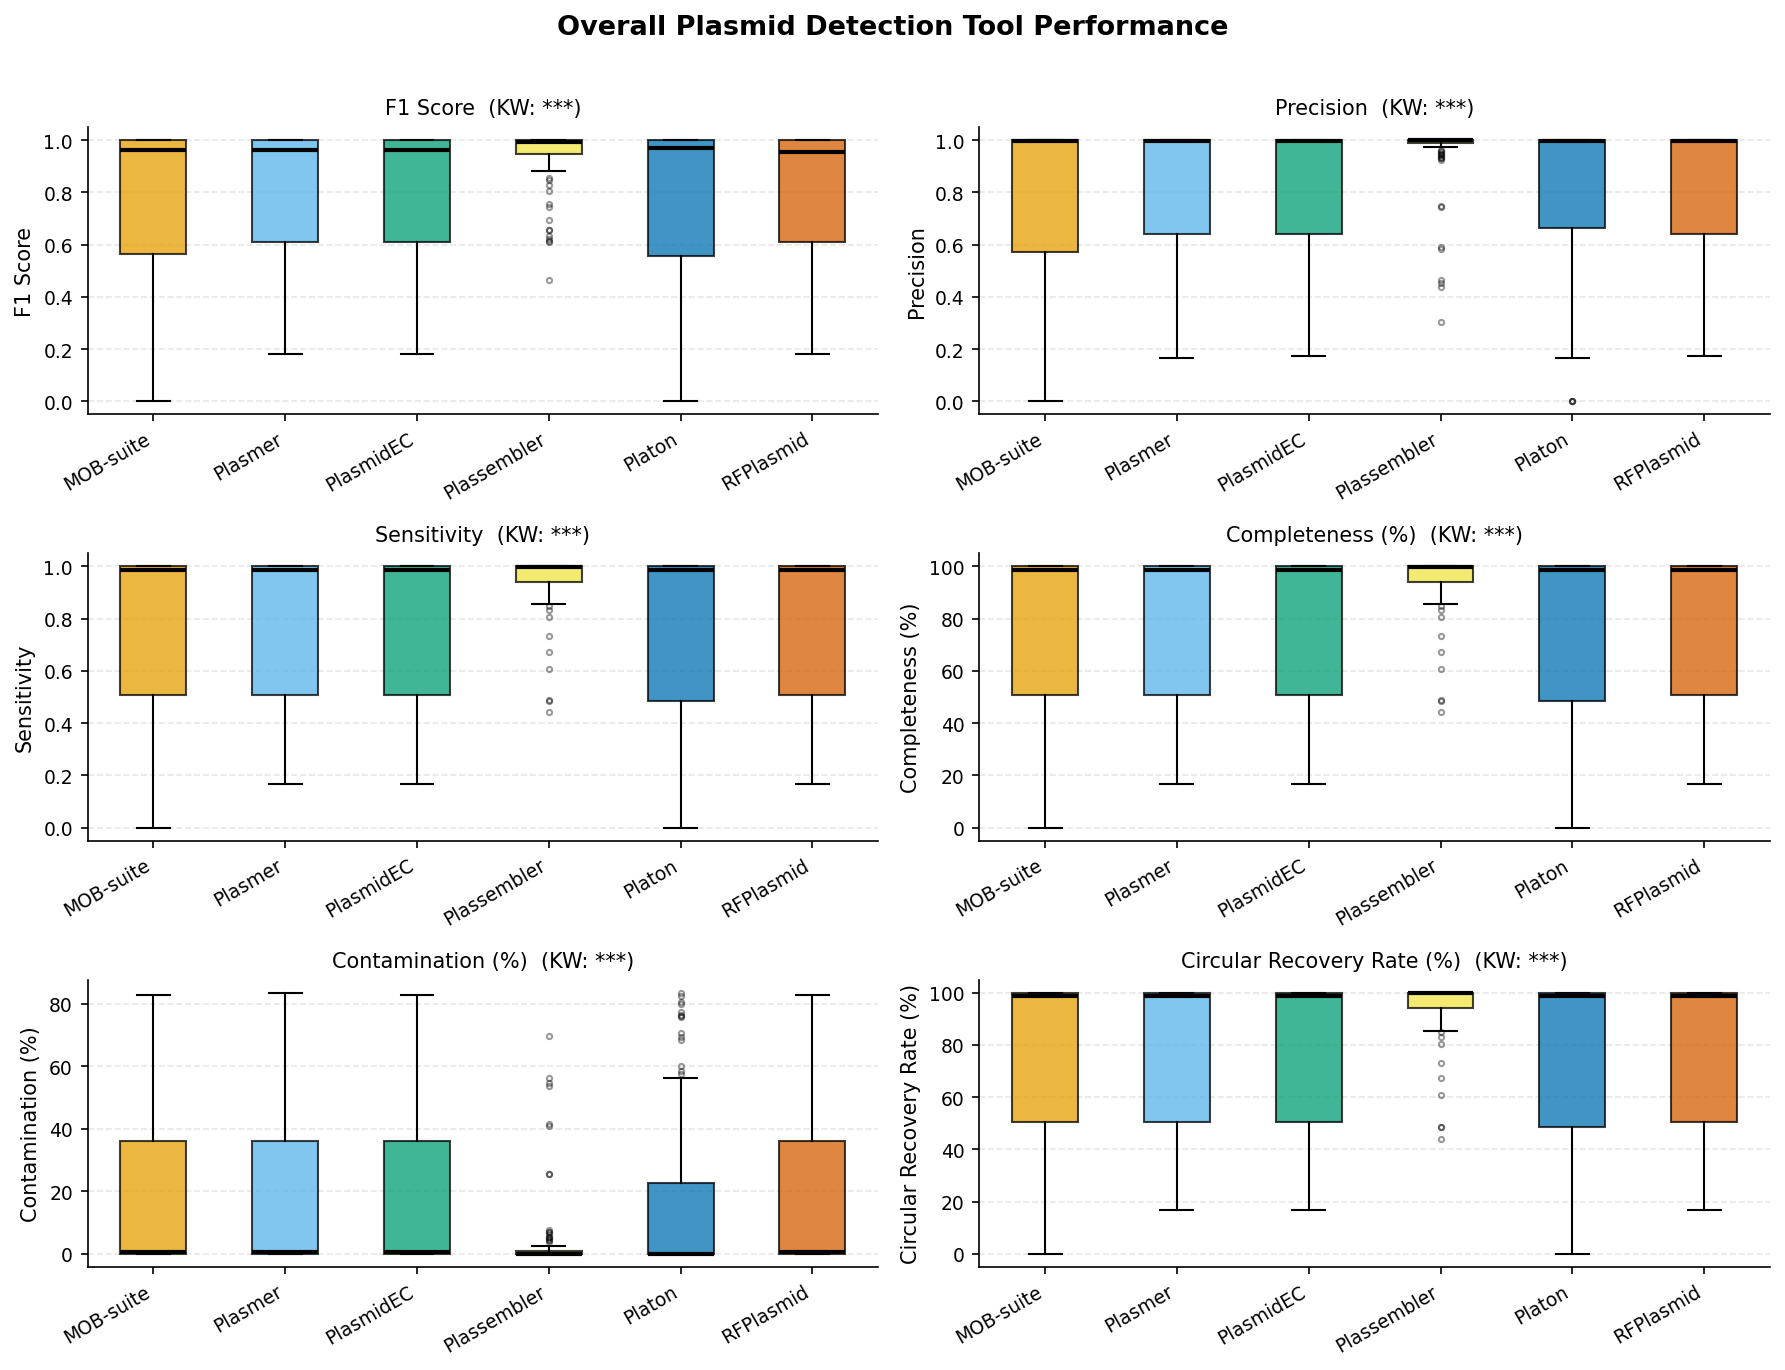

In [13]:
# --- Figure 1: Overall performance ----------------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
fig.suptitle('Overall Plasmid Detection Tool Performance', fontsize=13, fontweight='bold', y=1.01)

for ax, (metric, label) in zip(axes.flat, METRICS_MAPPING):
    data = [df[df['Tool'] == t][metric].dropna().values for t in TOOLS]
    bp = ax.boxplot(data, patch_artist=True, labels=TOOLS,
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='o', markersize=2.5, alpha=0.4),
                    widths=0.5)
    for patch, tool in zip(bp['boxes'], TOOLS):
        patch.set_facecolor(TOOL_COLORS[tool])
        patch.set_alpha(0.75)
    ax.set_ylabel(label)
    ax.set_xticklabels(TOOLS, rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)
    sig = kw_label(metric)
    ax.set_title(f'{label}  (KW: {sig})', fontsize=10)

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig1_overall_performance.png", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUTPUT_DIR}/fig1_overall_performance.pdf", bbox_inches='tight')
plt.show()


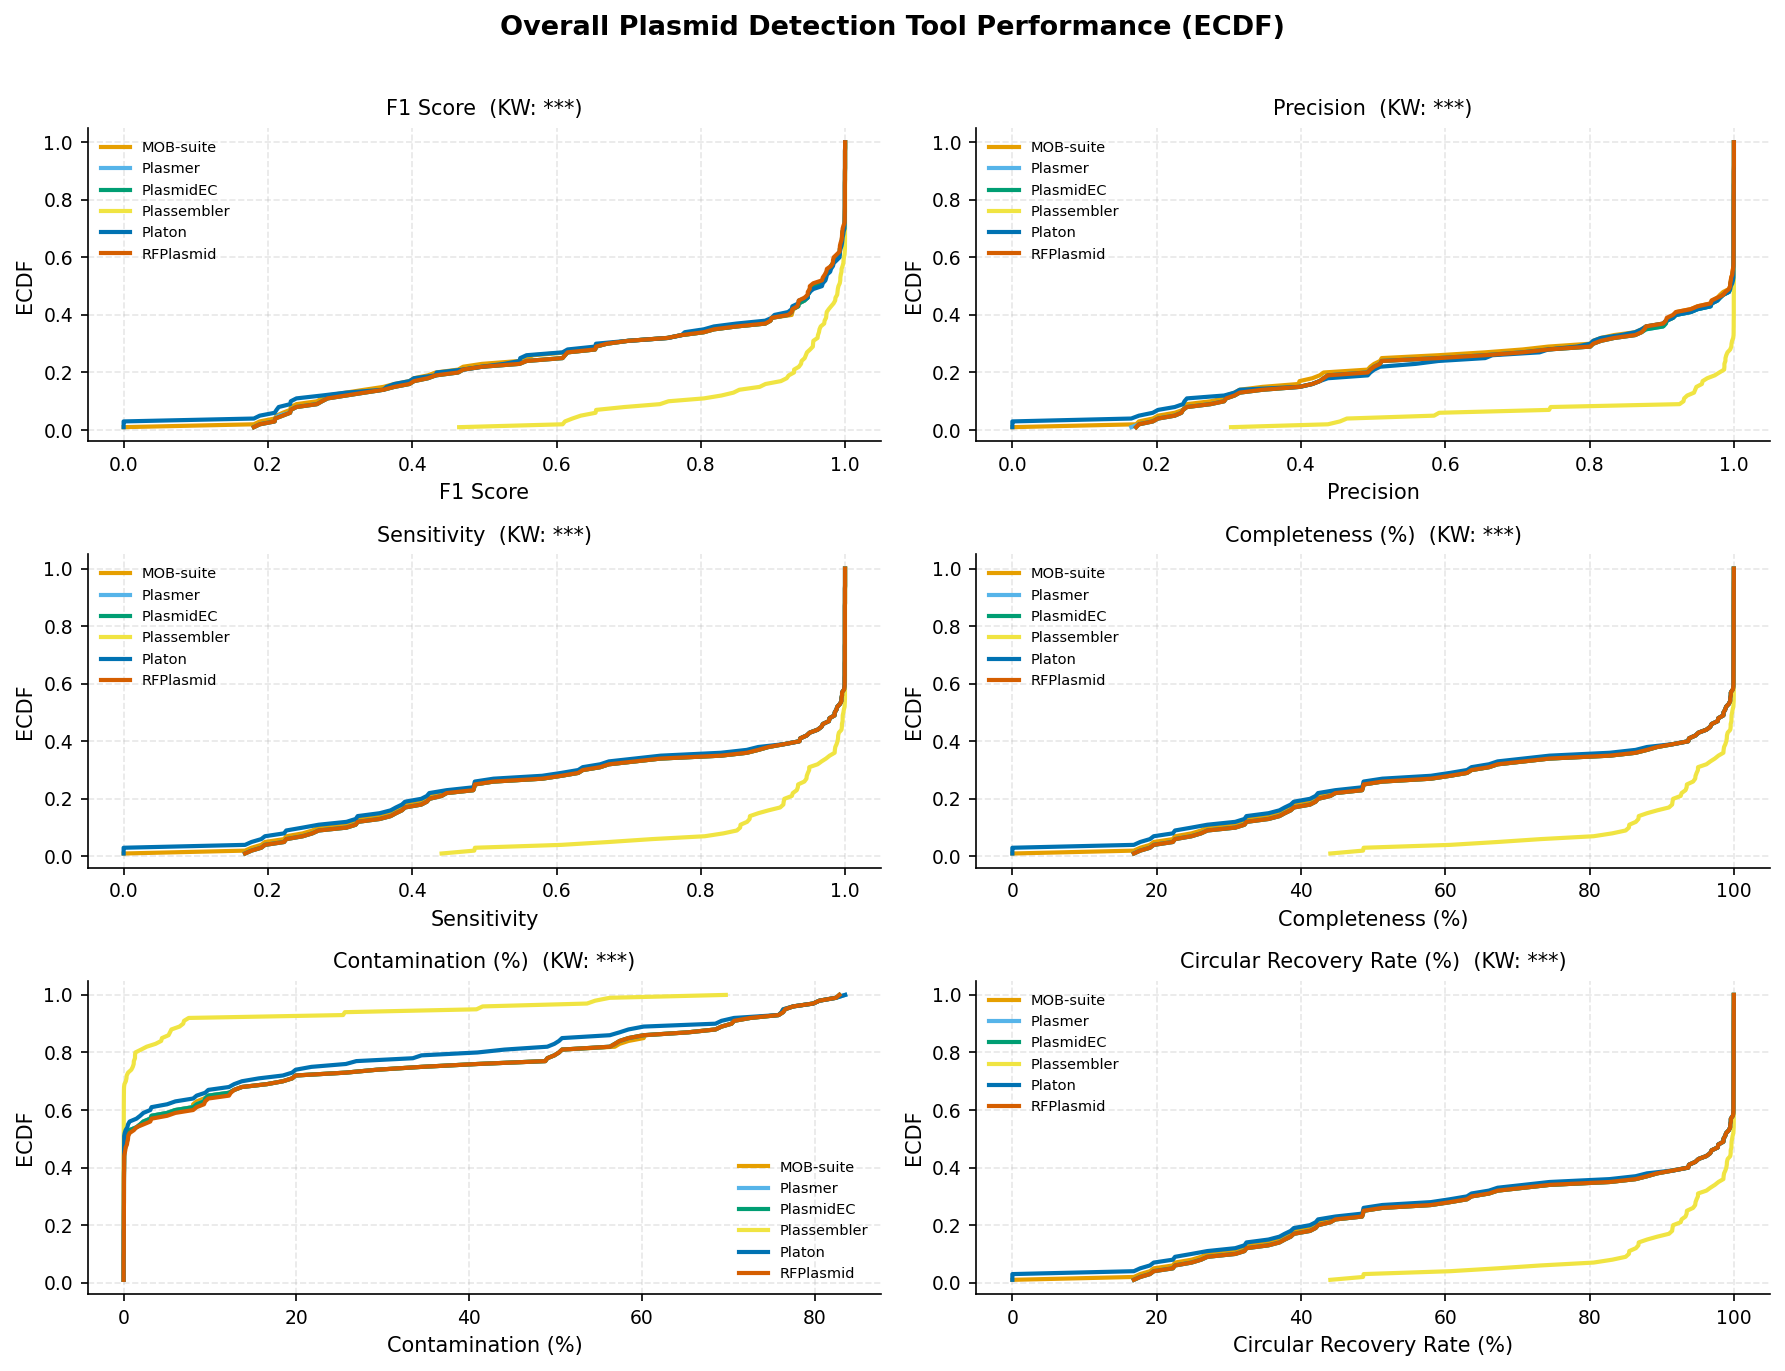

In [14]:
# --- Figure 1: Overall performance (ECDF) -------------------------------------------------------
fig, axes = plt.subplots(3, 2, figsize=(12, 9))
fig.suptitle('Overall Plasmid Detection Tool Performance (ECDF)', fontsize=13, fontweight='bold', y=1.01)

for ax, (metric, label) in zip(axes.flat, METRICS_MAPPING):
    for tool in TOOLS:
        data = np.sort(df[df['Tool'] == tool][metric].dropna().values)
        if len(data) == 0:
            continue

        y = np.arange(1, len(data) + 1) / len(data)
        ax.plot(data, y, label=tool, color=TOOL_COLORS[tool], linewidth=2)

    ax.set_xlabel(label)
    ax.set_ylabel('ECDF')
    ax.grid(alpha=0.3, linestyle='--', linewidth=0.8)

    sig = kw_label(metric)
    ax.set_title(f'{label}  (KW: {sig})', fontsize=10)

    ax.legend(fontsize=7, frameon=False)

plt.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/fig1_overall_performance_ecdf.png", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUTPUT_DIR}/fig1_overall_performance_ecdf.pdf", bbox_inches='tight')
plt.show()


F1_Score | MOB-suite | ONT mean=0.9792, zero=0.0% | PacBio mean=0.5949, zero=2.0%
F1_Score | Plasmer | ONT mean=0.9791, zero=0.0% | PacBio mean=0.6078, zero=0.0%
F1_Score | PlasmidEC | ONT mean=0.9791, zero=0.0% | PacBio mean=0.6079, zero=0.0%
F1_Score | Plassembler | ONT mean=0.9843, zero=0.0% | PacBio mean=0.8982, zero=0.0%
F1_Score | Platon | ONT mean=0.9802, zero=0.0% | PacBio mean=0.5810, zero=6.0%
F1_Score | RFPlasmid | ONT mean=0.9778, zero=0.0% | PacBio mean=0.6080, zero=0.0%
Precision | MOB-suite | ONT mean=0.9725, zero=0.0% | PacBio mean=0.6265, zero=2.0%
Precision | Plasmer | ONT mean=0.9722, zero=0.0% | PacBio mean=0.6471, zero=0.0%
Precision | PlasmidEC | ONT mean=0.9722, zero=0.0% | PacBio mean=0.6472, zero=0.0%
Precision | Plassembler | ONT mean=0.9816, zero=0.0% | PacBio mean=0.9306, zero=0.0%
Precision | Platon | ONT mean=0.9744, zero=0.0% | PacBio mean=0.6307, zero=6.0%
Precision | RFPlasmid | ONT mean=0.9698, zero=0.0% | PacBio mean=0.6474, zero=0.0%
Sensitivity | MO

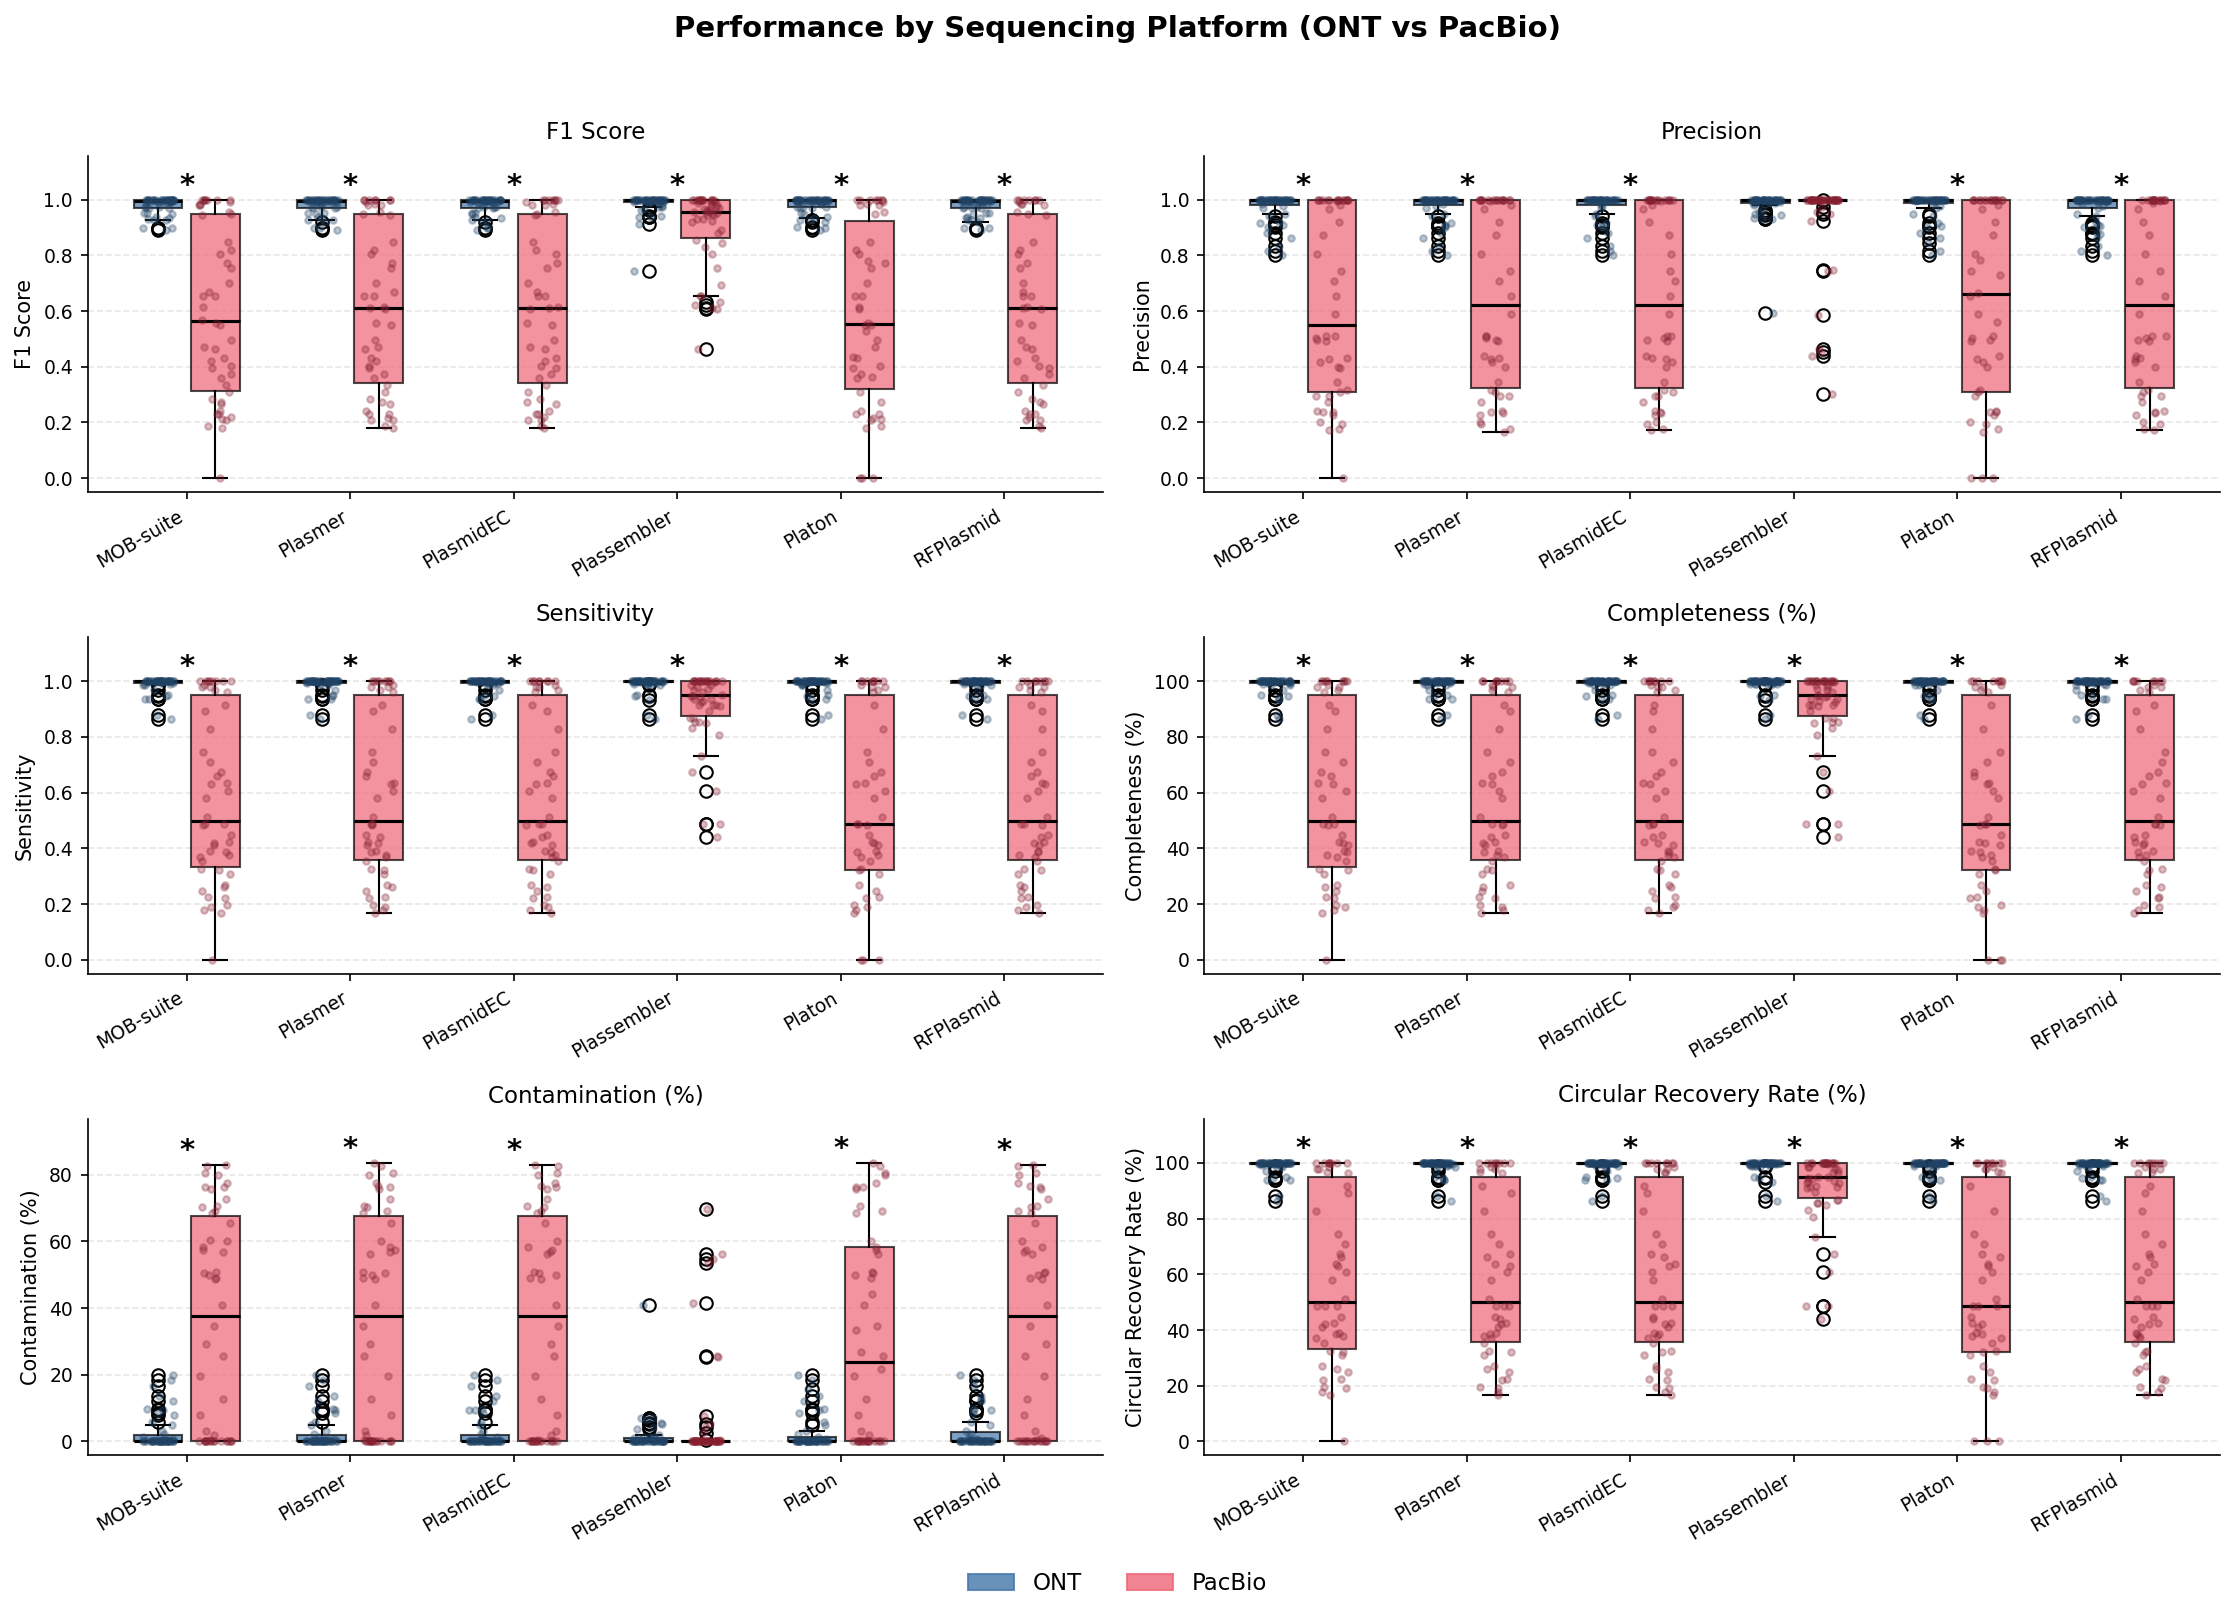


Platform comparison statistical results:
             Metric        Tool  ONT_N  PacBio_N  ONT_Mean  ONT_Zero_Pct  PacBio_Mean  PacBio_Zero_Pct  Statistic      P_Value
           F1_Score   MOB-suite     50        50  0.979250           0.0     0.594906              2.0     2147.5 6.087122e-10
           F1_Score     Plasmer     50        50  0.979096           0.0     0.607804              0.0     2147.5 6.087122e-10
           F1_Score   PlasmidEC     50        50  0.979096           0.0     0.607918              0.0     2147.5 6.087122e-10
           F1_Score Plassembler     50        50  0.984286           0.0     0.898206              0.0     1797.0 1.508862e-04
           F1_Score      Platon     50        50  0.980238           0.0     0.581030              6.0     2166.5 2.618314e-10
           F1_Score   RFPlasmid     50        50  0.977772           0.0     0.607990              0.0     2137.5 9.455292e-10
          Precision   MOB-suite     50        50  0.972544           

In [15]:
# --- Figure 2: Platform comparison (ONT vs PacBio) ----------------------------

fig, axes = plt.subplots(3, 2, figsize=(15, 11))
fig.suptitle('Performance by Sequencing Platform (ONT vs PacBio)', fontsize=14, fontweight='bold', y=0.98)

platform_stats = []

# Define standard x positions for tools
x = np.arange(len(TOOLS))
w = 0.35

for ax, (metric, label) in zip(axes.flat, METRICS_MAPPING):

    # Pre-extract platform series for speed
    df_metric = df.dropna(subset=[metric])
    
    ont_data = [
        df_metric[(df_metric['Tool'] == t) & (df_metric['Platform'] == 'ONT')][metric].values
        for t in TOOLS
    ]

    pacb_data = [
        df_metric[(df_metric['Tool'] == t) & (df_metric['Platform'] == 'PacBio')][metric].values
        for t in TOOLS
    ]

    max_y_observed = -np.inf

    for i, (tool, o_vals, p_vals) in enumerate(zip(TOOLS, ont_data, pacb_data)):

        # ------------------------------------------------------------
        # 1. CHECK MEANS & ZERO PERCENTAGES
        # ------------------------------------------------------------
        ont_mean = np.mean(o_vals) if len(o_vals) > 0 else np.nan
        pacb_mean = np.mean(p_vals) if len(p_vals) > 0 else np.nan

        ont_zero_pct = (
            np.mean(o_vals == 0) * 100
            if len(o_vals) > 0 else np.nan
        )

        pacb_zero_pct = (
            np.mean(p_vals == 0) * 100
            if len(p_vals) > 0 else np.nan
        )

        print(
            f"{metric} | {tool} | "
            f"ONT mean={ont_mean:.4f}, zero={ont_zero_pct:.1f}% | "
            f"PacBio mean={pacb_mean:.4f}, zero={pacb_zero_pct:.1f}%"
        )

        # ------------------------------------------------------------
        # 2. STATISTICAL TEST: ONT vs PacBio
        # ------------------------------------------------------------
        if len(o_vals) > 0 and len(p_vals) > 0:
            stat, p_value = mannwhitneyu(o_vals, p_vals, alternative='two-sided')
        else:
            stat, p_value = np.nan, np.nan

        platform_stats.append({
            'Metric': metric,
            'Tool': tool,
            'ONT_N': len(o_vals),
            'PacBio_N': len(p_vals),
            'ONT_Mean': ont_mean,
            'ONT_Zero_Pct': ont_zero_pct,
            'PacBio_Mean': pacb_mean,
            'PacBio_Zero_Pct': pacb_zero_pct,
            'Statistic': stat,
            'P_Value': p_value
        })

        # ------------------------------------------------------------
        # 3. BOXPLOTS & STRIP PLOTS
        # ------------------------------------------------------------
        pos_ont = x[i] - w / 2
        pos_pacb = x[i] + w / 2

        # ONT Box & Jitter Points
        if len(o_vals) > 0:
            ax.boxplot(
                [o_vals],
                positions=[pos_ont],
                widths=w * 0.85,
                patch_artist=True,
                manage_ticks=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(facecolor='#4477AA', alpha=0.7)
            )
            ont_jitter = np.random.uniform(-0.10, 0.10, size=len(o_vals))
            ax.scatter(
                pos_ont + ont_jitter,
                o_vals,
                color='#224466',
                alpha=0.3,
                s=10,
                zorder=3
            )

        # PacBio Box & Jitter Points
        if len(p_vals) > 0:
            ax.boxplot(
                [p_vals],
                positions=[pos_pacb],
                widths=w * 0.85,
                patch_artist=True,
                manage_ticks=False,
                medianprops=dict(color='black', linewidth=1.5),
                boxprops=dict(facecolor='#EE6677', alpha=0.7)
            )
            pacb_jitter = np.random.uniform(-0.10, 0.10, size=len(p_vals))
            ax.scatter(
                pos_pacb + pacb_jitter,
                p_vals,
                color='#882233',
                alpha=0.3,
                s=10,
                zorder=3
            )

        # Track max y for plot headroom scaling
        combined = np.concatenate([o_vals, p_vals]) if len(o_vals) or len(p_vals) else []
        if len(combined) > 0:
            local_max = np.max(combined)
            if local_max > max_y_observed:
                max_y_observed = local_max

        # ------------------------------------------------------------
        # 4. ADD SIGNIFICANCE STAR
        # ------------------------------------------------------------
        if not np.isnan(p_value) and p_value < 0.05 and len(combined) > 0:
            local_top = np.max(combined)
            ax.text(
                x[i],
                local_top,
                '*',
                ha='center',
                va='bottom',
                fontsize=14,
                fontweight='bold',
                color='black'
            )

    # ------------------------------------------------------------
    # AXIS SETTINGS
    # ------------------------------------------------------------
    ax.set_xticks(x)
    ax.set_xticklabels(TOOLS, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(label, fontsize=11, pad=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.8)

    # Scale Y axis to give significance stars headroom
    if not np.isinf(max_y_observed):
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(y_min, max_y_observed + (max_y_observed - y_min) * 0.15)


# ----------------------------------------------------------------
# LEGEND & LAYOUT
# ----------------------------------------------------------------

handles = [
    mpatches.Patch(color='#4477AA', alpha=0.8, label='ONT'),
    mpatches.Patch(color='#EE6677', alpha=0.8, label='PacBio')
]

fig.legend(
    handles=handles,
    frameon=True,
    facecolor='white',
    edgecolor='none',
    loc='lower center',
    ncol=2,
    fontsize=11,
    bbox_to_anchor=(0.5, 0.01)
)

plt.tight_layout(rect=[0, 0.04, 1, 0.96])

# Save Outputs
fig.savefig(f"{OUTPUT_DIR}/fig2_platform_comparison.png", dpi=300, bbox_inches='tight')
fig.savefig(f"{OUTPUT_DIR}/fig2_platform_comparison.pdf", bbox_inches='tight')
plt.show()

# Export Statistical Results (Includes zero % metrics)
platform_stats_df = pd.DataFrame(platform_stats)
platform_stats_df.to_csv(f"{OUTPUT_DIR}/table2_platform_comparison_statistics.csv", index=False)

print("\nPlatform comparison statistical results:")
print(platform_stats_df.to_string(index=False))


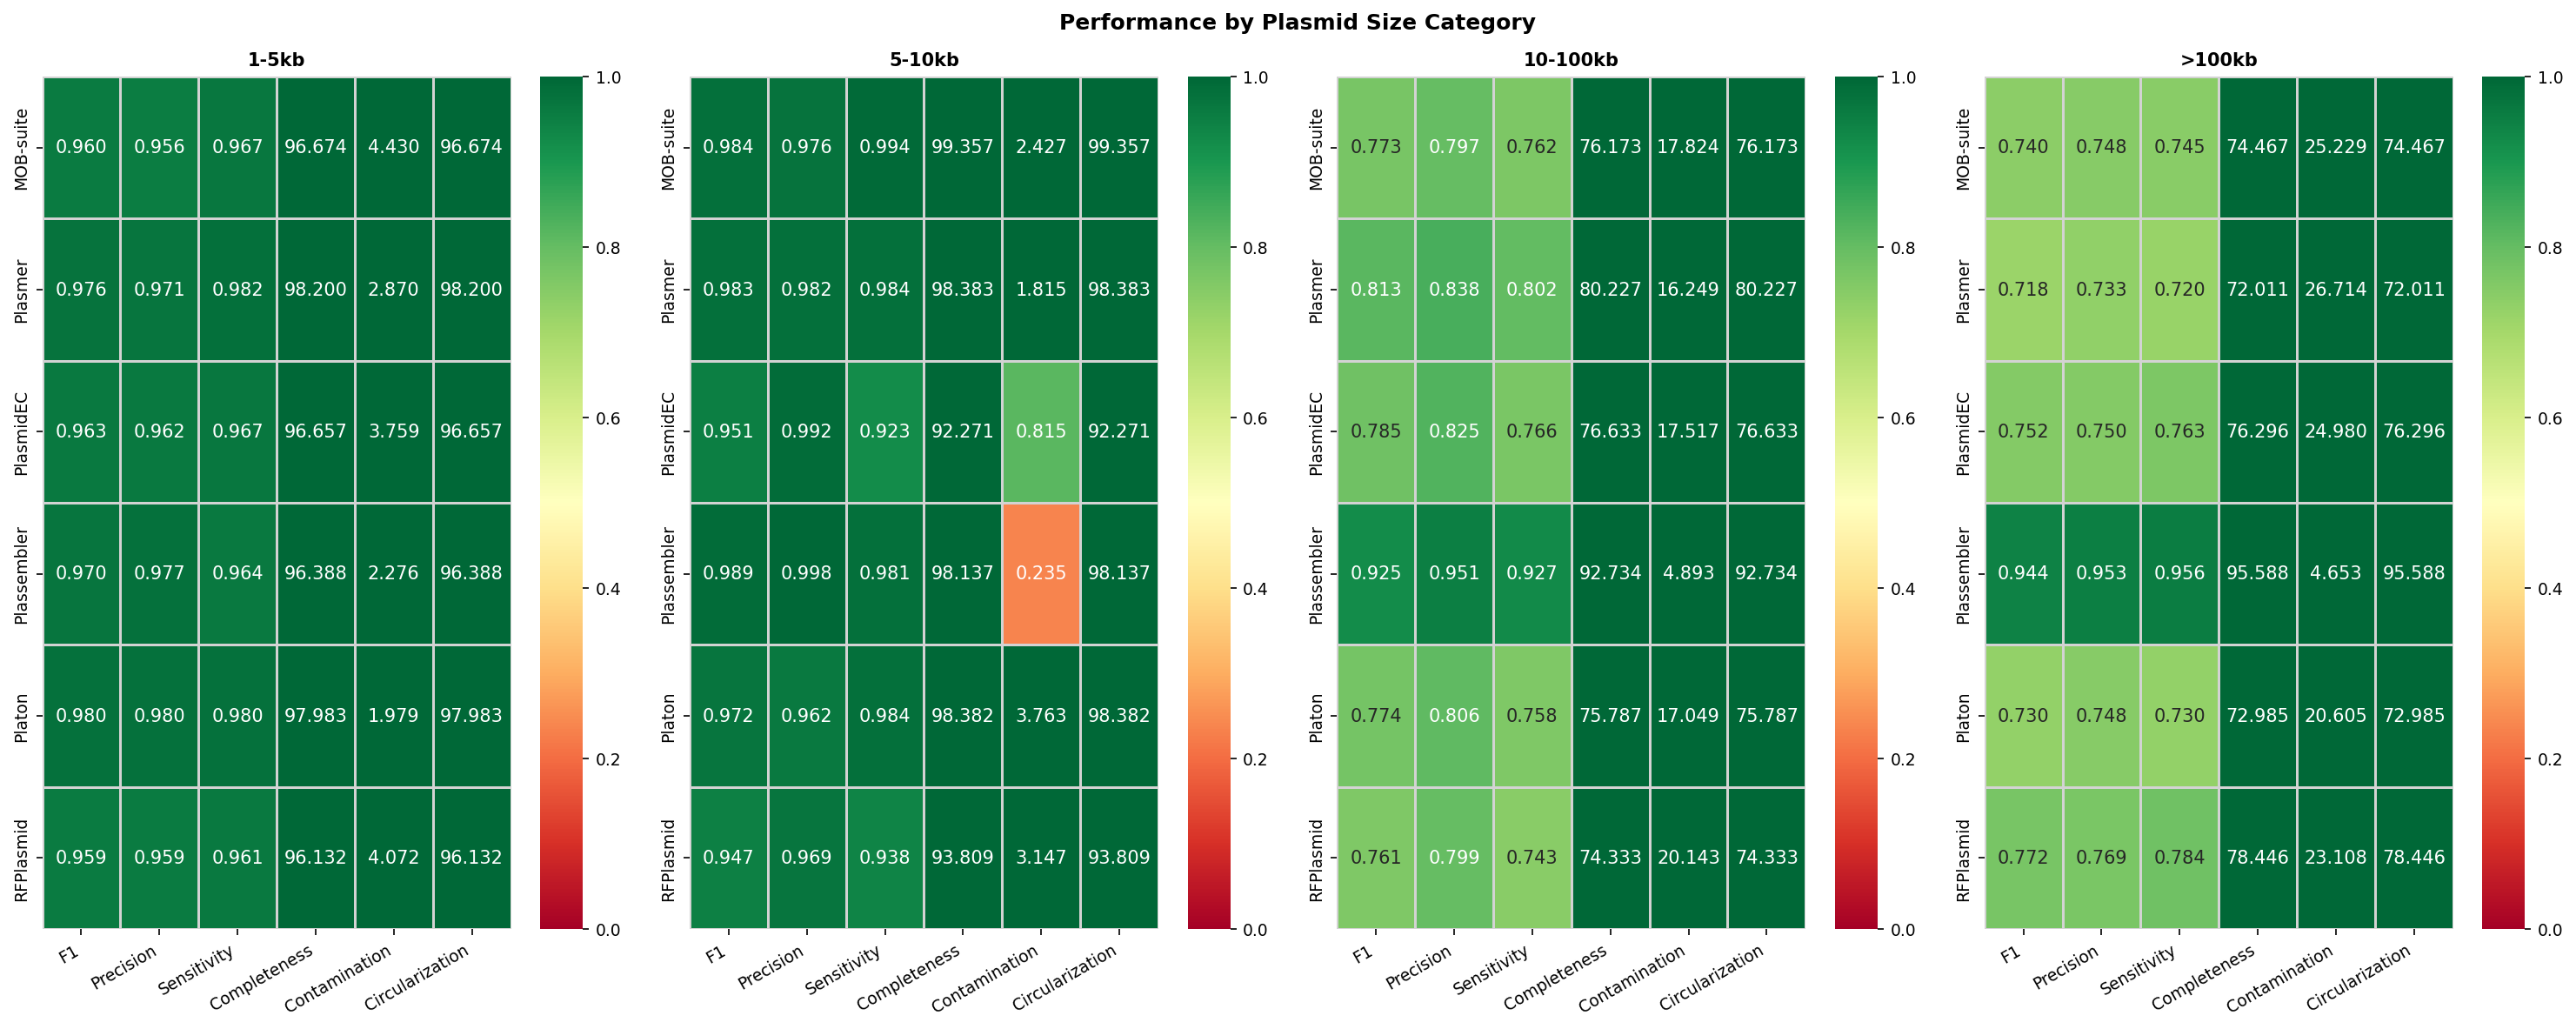

In [16]:
# --- Figure 3: Size-stratified heatmap ----------------------------------------------
valid_sizes = [sz for sz in size_cats if sz in df['Size_Category'].unique()]
if valid_sizes:
    fig, axes = plt.subplots(1, len(valid_sizes),
                             figsize=(5 * len(valid_sizes), 8),
                             squeeze=False)
    fig.suptitle('Performance by Plasmid Size Category', fontsize=12, fontweight='bold')
    #plot_metrics_heat = ['Sensitivity', 'Precision', 'F1_Score', 'Mean_Completeness']

    for ax, sz in zip(axes[0], valid_sizes):
        pivot = (df[df['Size_Category'] == sz]
                   .groupby('Tool')[METRICS]
                   .mean().round(3))
        pivot.columns = ['F1', 'Precision', 'Sensitivity', 'Completeness', 'Contamination', 'Circularization']
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=ax, cbar=True,
                    linewidths=0.5, linecolor='lightgrey')
        ax.set_title(f'{sz}', fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        ax.set_xticklabels(pivot.columns, rotation=30, ha='right')
        ax.set_ylabel('')

    plt.tight_layout()
    fig.savefig(f"{OUTPUT_DIR}/fig3_size_stratified.png", dpi=300, bbox_inches='tight')
    fig.savefig(f"{OUTPUT_DIR}/fig3_size_stratified.pdf", bbox_inches='tight')
    plt.show()


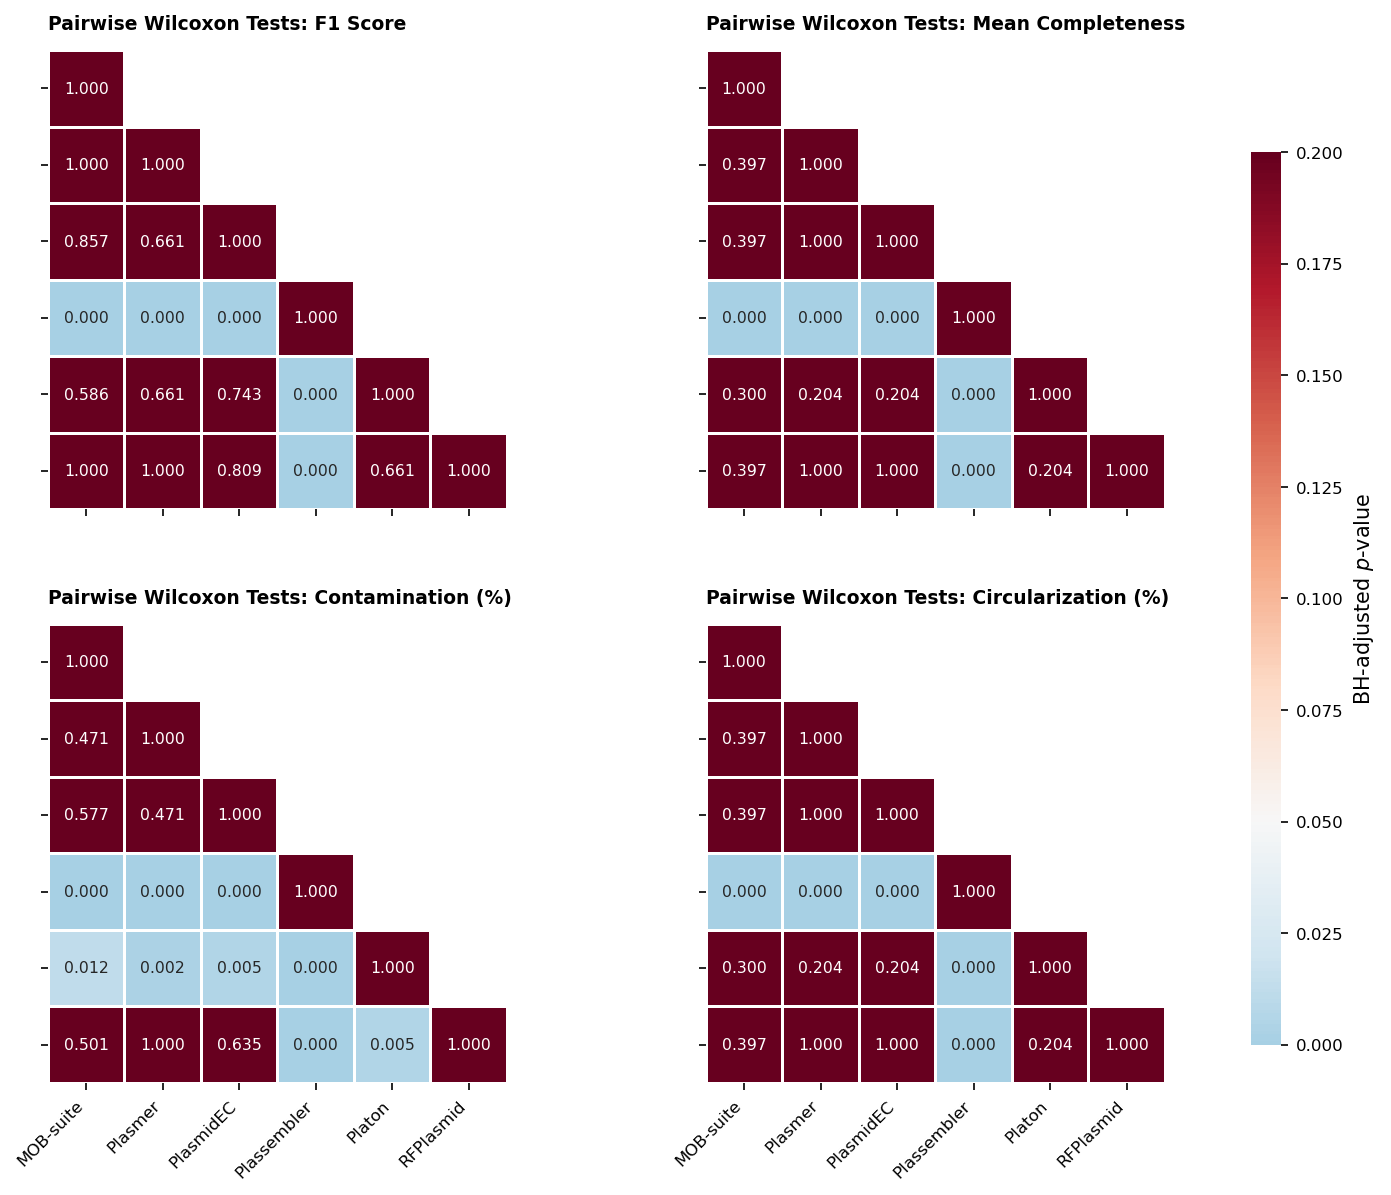

In [17]:
# --- Figure 4: Pairwise Wilcoxon Sign-Ranked Tests -------------------------------

# Configure publication-style typography & general layout
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

metrics = [
    ("F1_Score", "F1 Score"),
    ("Mean_Completeness", "Mean Completeness"),
    ("Contamination_Pct", "Contamination (%)"),
    ("Circularization_Pct", "Circularization (%)"),
]

panel_labels = ["A", "B", "C", "D"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8.5), sharex=True, sharey=True)
axes = axes.flatten()

# Common colorbar normalization and artist handle
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]

for idx, (metric_key, display_name) in enumerate(metrics):
    ax = axes[idx]

    if metric_key in posthoc_results:
        # Build symmetrical matrix
        mat = pd.DataFrame(
            np.ones((len(TOOLS), len(TOOLS))), index=TOOLS, columns=TOOLS
        )

        for _, row in posthoc_results[metric_key].iterrows():
            mat.loc[row["Tool_1"], row["Tool_2"]] = row["p.adj"]
            mat.loc[row["Tool_2"], row["Tool_1"]] = row["p.adj"]

        mask = np.triu(np.ones_like(mat, dtype=bool), k=1)

        # Plot heatmap
        sns.heatmap(
            mat,
            annot=True,
            fmt=".3f",
            cmap="RdBu_r",
            center=ALPHA,
            vmin=0.0,
            vmax=0.2,
            mask=mask,
            ax=ax,
            linewidths=0.5,
            linecolor="white",
            square=True,
            cbar=(idx == 0),  # Generate cbar artist on first plot only
            cbar_ax=cbar_ax if idx == 0 else None,
            cbar_kws={"label": "BH-adjusted $p$-value"} if idx == 0 else None,
            annot_kws={"size": 7.5, "weight": "normal"},
        )

        # Set title per subplot
        ax.set_title(f"Pairwise Wilcoxon Tests: {display_name}", loc="left", fontsize=9, fontweight="bold", pad=10)

        # Rotate tick labels cleanly
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    else:
        ax.text(0.5, 0.5, f"No data for {display_name}", ha="center", va="center")
        ax.axis("off")

# Adjust spacing to leave room for panel labels and shared colorbar
plt.subplots_adjust(left=0.08, right=0.90, top=0.93, bottom=0.12, hspace=0.25, wspace=0.15)

# Save high-resolution publication formats
fig.savefig(
    f"{OUTPUT_DIR}/fig4_posthoc_pairwise_journal.png", dpi=300, bbox_inches="tight"
)
fig.savefig(
    f"{OUTPUT_DIR}/fig4_posthoc_pairwise_journal.pdf", bbox_inches="tight"
)
plt.show()


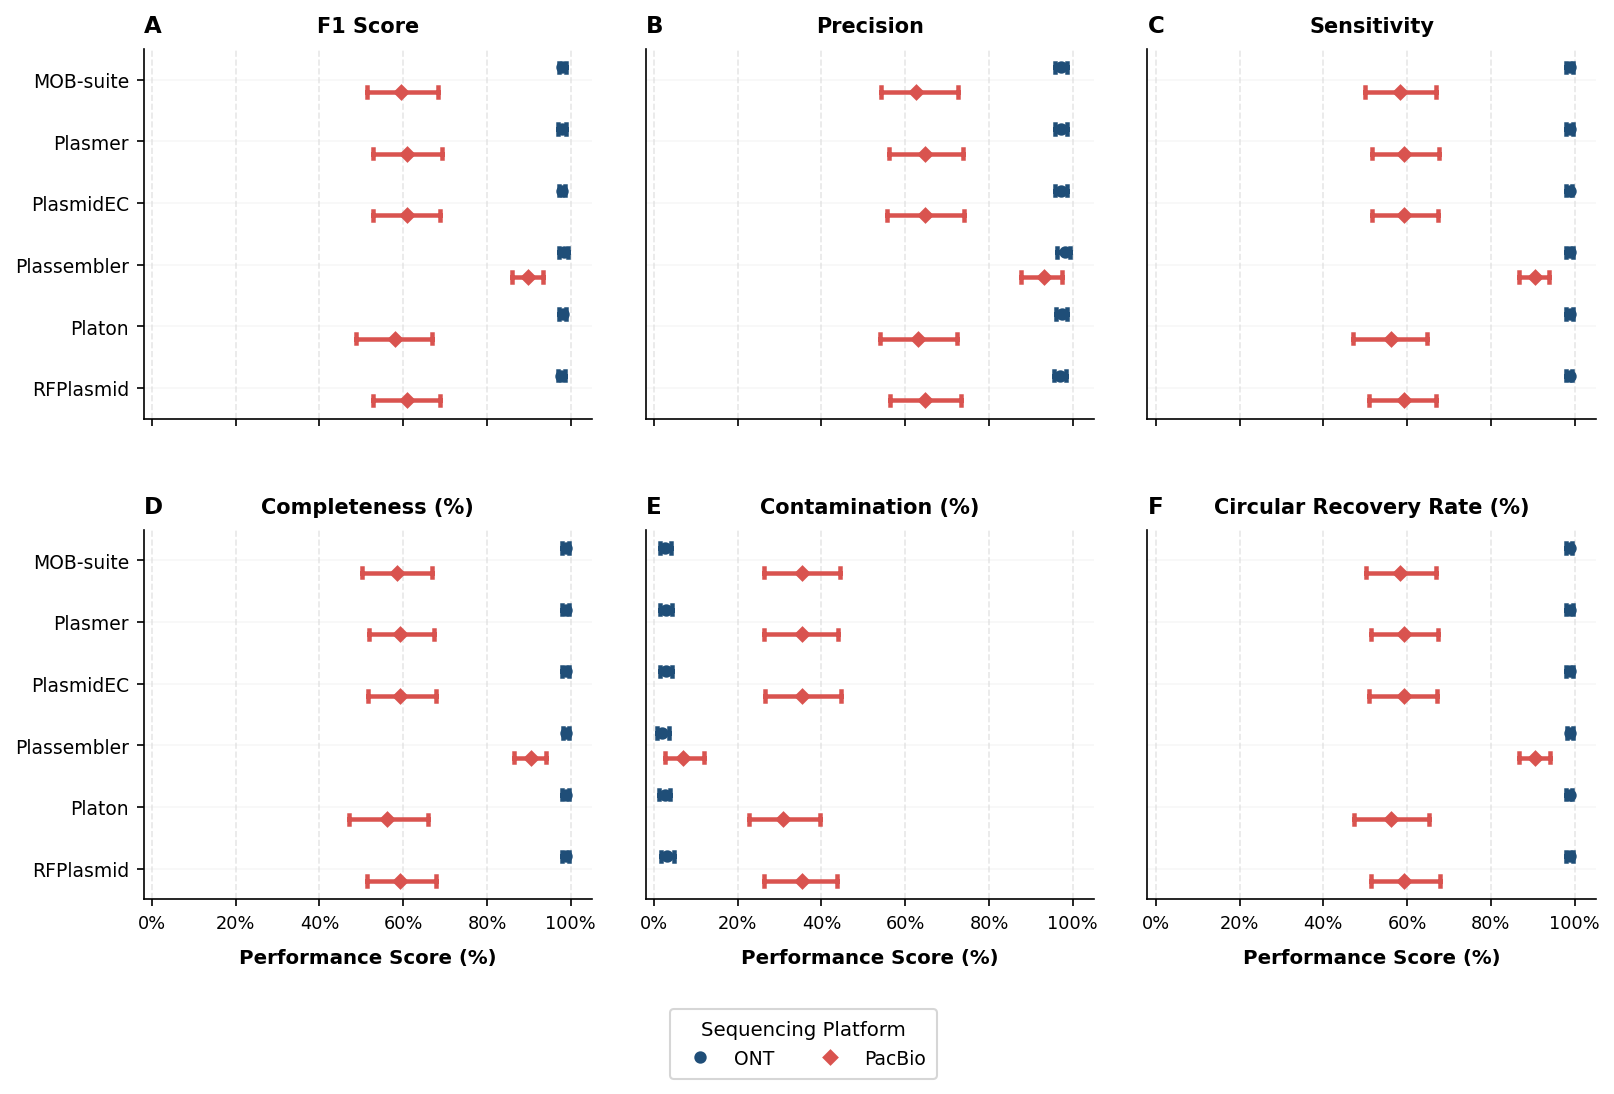

In [18]:
# --- Figure 5: Benchmark 6-panel combined matrix  ---------------------------------------------

# Set publication-grade typography and global style
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 9,
        "figure.titlesize": 12,
    }
)

# Filter dataset for E. coli only
df_ecoli = df[df["Species"].astype(str).str.contains("coli", case=False, na=False)].copy()

# Map metrics and normalize scale (0-1 -> 0-100%)
METRICS_MAPPING_dict = dict(METRICS_MAPPING)
SCALE_0_TO_1_METRICS = ["F1_Score", "Precision", "Sensitivity"]

df_melted = df_ecoli.melt(
    id_vars=["Tool", "Platform"],
    value_vars=list(METRICS_MAPPING_dict.keys()),
    var_name="Metric_Raw",
    value_name="Value",
)

df_melted["Value"] = np.where(
    df_melted["Metric_Raw"].isin(SCALE_0_TO_1_METRICS),
    df_melted["Value"] * 100.0,
    df_melted["Value"]
)

df_melted["Metric"] = df_melted["Metric_Raw"].map(METRICS_MAPPING_dict)
df_melted["Tool"] = pd.Categorical(df_melted["Tool"], categories=TOOLS, ordered=True)
df_melted = df_melted.dropna(subset=["Value"])

# Aesthetics definition
PLATFORM_ORDER = ["ONT", "PacBio"]
PLATFORM_COLORS = {"ONT": "#1f4e78", "PacBio": "#d9534f"}  # High-contrast Navy & Coral
PLATFORM_MARKERS = {"ONT": "o", "PacBio": "D"}

panel_tags = ["A", "B", "C", "D", "E", "F"]
metric_list = list(METRICS_MAPPING_dict.values())

# Create 2x3 Subplot Canvas
fig, axes = plt.subplots(2, 3, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.flatten()

for idx, metric_name in enumerate(metric_list):
    ax = axes[idx]
    sub_data = df_melted[df_melted["Metric"] == metric_name]

    # Draw pointplots with confidence intervals
    sns.pointplot(
        data=sub_data,
        x="Value",
        y="Tool",
        hue="Platform",
        hue_order=PLATFORM_ORDER,
        palette=PLATFORM_COLORS,
        markers=[PLATFORM_MARKERS[p] for p in PLATFORM_ORDER],
        dodge=0.4,
        join=False,
        errorbar="ci",
        capsize=0.15,
        scale=0.8,
        ax=ax,
    )

    # Grid alignment
    ax.set_xlim(-2, 105)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda val, p: f"{int(val)}%"))
    ax.grid(axis="x", linestyle="--", alpha=0.35, color="#bbbbbb", zorder=0)
    ax.grid(axis="y", linestyle="-", alpha=0.25, color="#e0e0e0", zorder=0)

    # Subfigure tags and titles (e.g., "A   F1 Score")
    ax.set_title(panel_tags[idx], loc="left", fontweight="bold", fontsize=11, pad=8)
    ax.set_title(metric_name, loc="center", fontweight="bold", fontsize=10, pad=8)

    # Clean per-subplot axes
    ax.set_xlabel("")
    ax.set_ylabel("")

    # Suppress redundant Y-ticks on internal plots
    if idx % 3 != 0:
        ax.tick_params(left=False)

    # Individual legend removal (Will add single global legend)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # Despine for clean academic frame
    sns.despine(ax=ax, top=True, right=True)

# 5. Add Horizontal X-axis labels to bottom row subplots
for ax in axes[3:]:
    ax.set_xlabel("Performance Score (%)", fontweight="bold", fontsize=9.5, labelpad=8)

# 6. Global Legend at Bottom
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles=handles,
    labels=labels,
    title="Sequencing Platform",
    title_fontsize=9.5,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.06),
    ncol=2,
    frameon=True,
    facecolor="white",
    edgecolor="#cccccc",
    borderpad=0.6,
)

# Adjust layout padding
plt.subplots_adjust(left=0.10, right=0.98, top=0.93, bottom=0.12, hspace=0.30, wspace=0.12)

# Save high-resolution publication formats
plt.savefig(
    f"{OUTPUT_DIR}/fig5_benchmark_6panel_ecoli_journal.png", dpi=300, bbox_inches="tight"
)
plt.savefig(
    f"{OUTPUT_DIR}/fig5_benchmark_6panel_ecoli_journal.pdf", bbox_inches="tight"
)
plt.show()


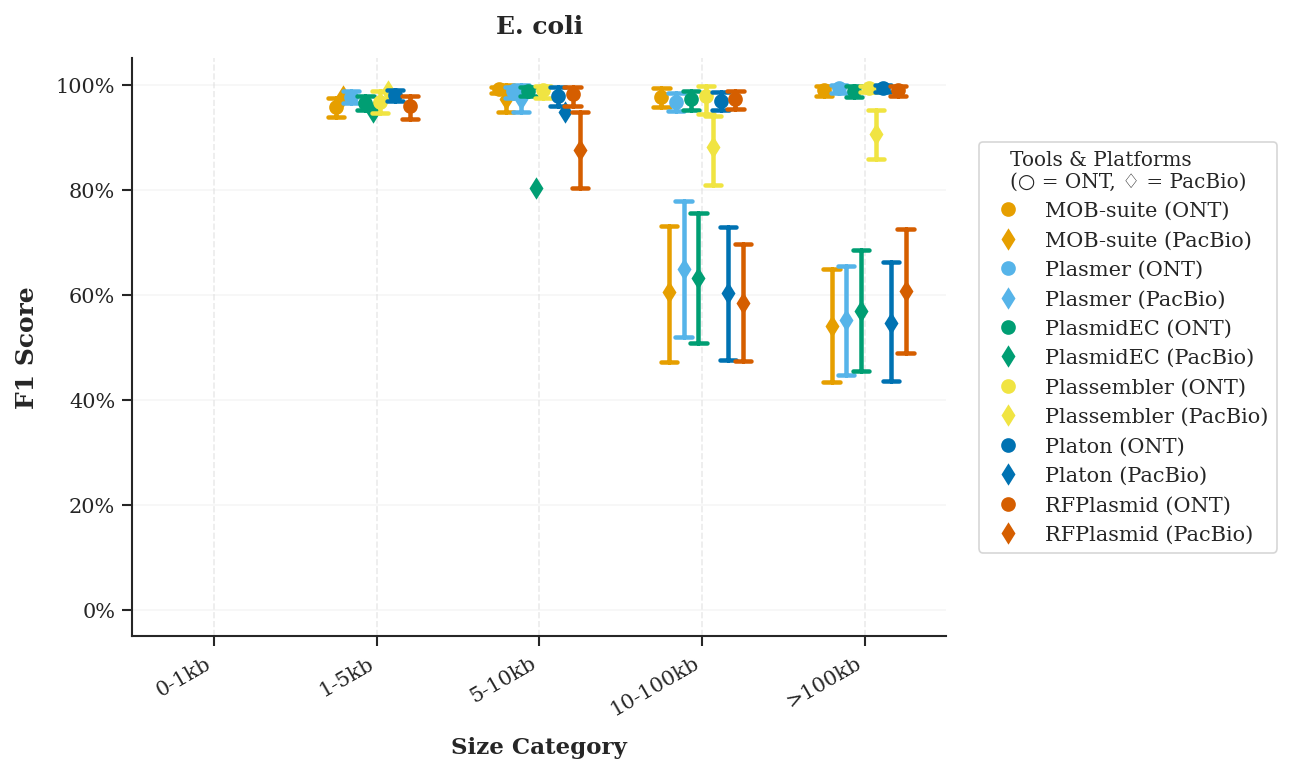

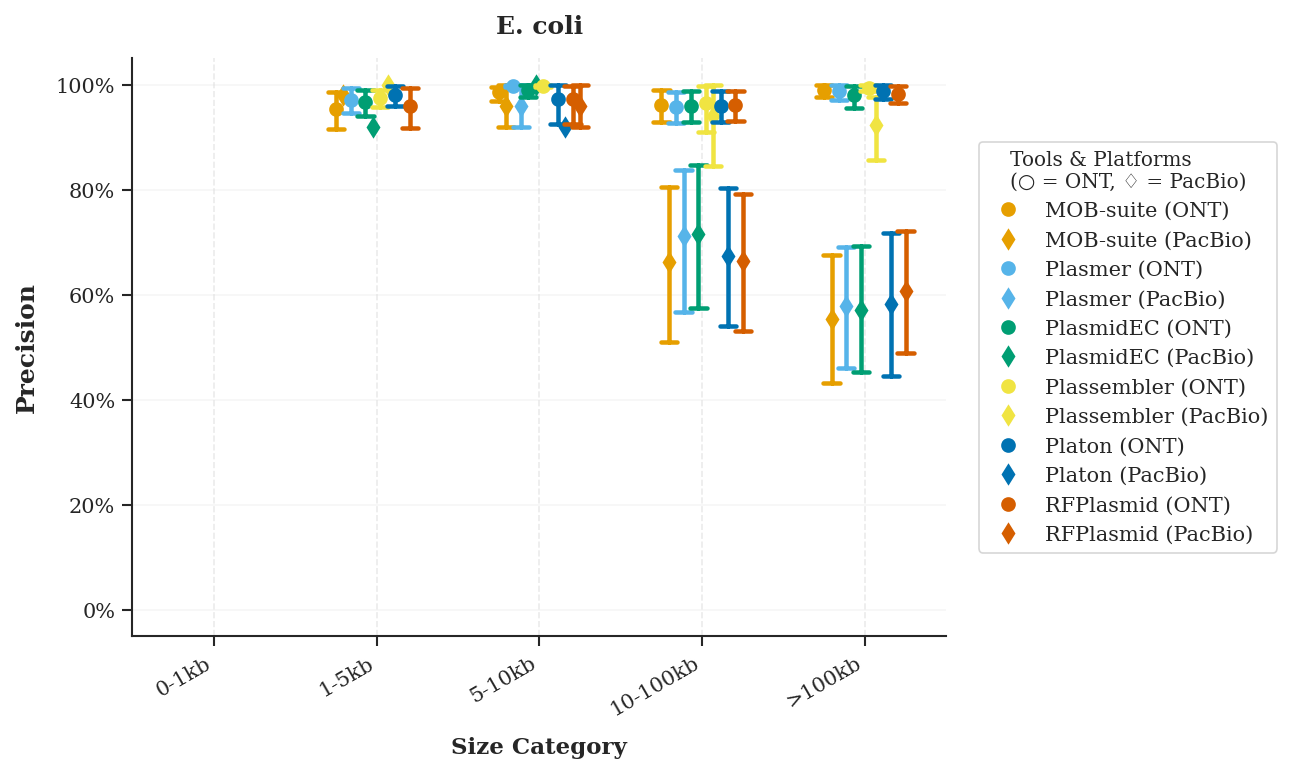

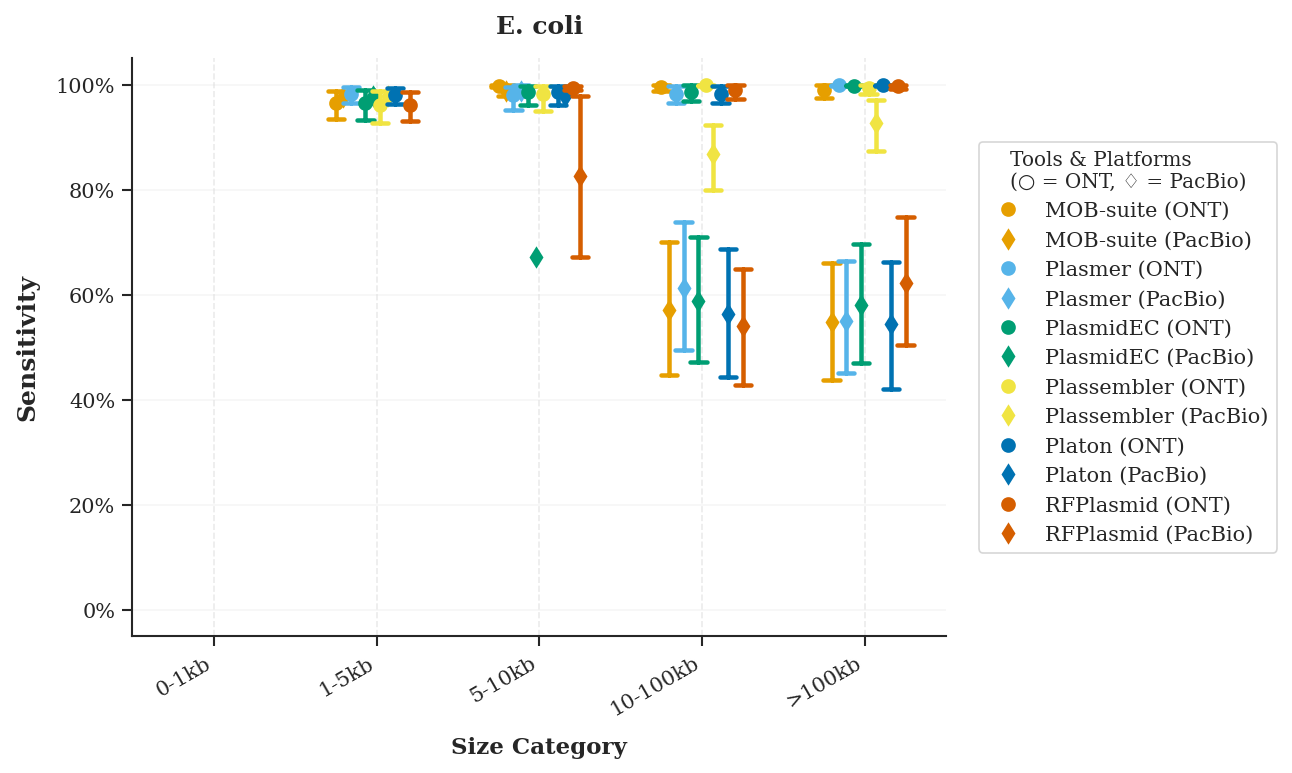

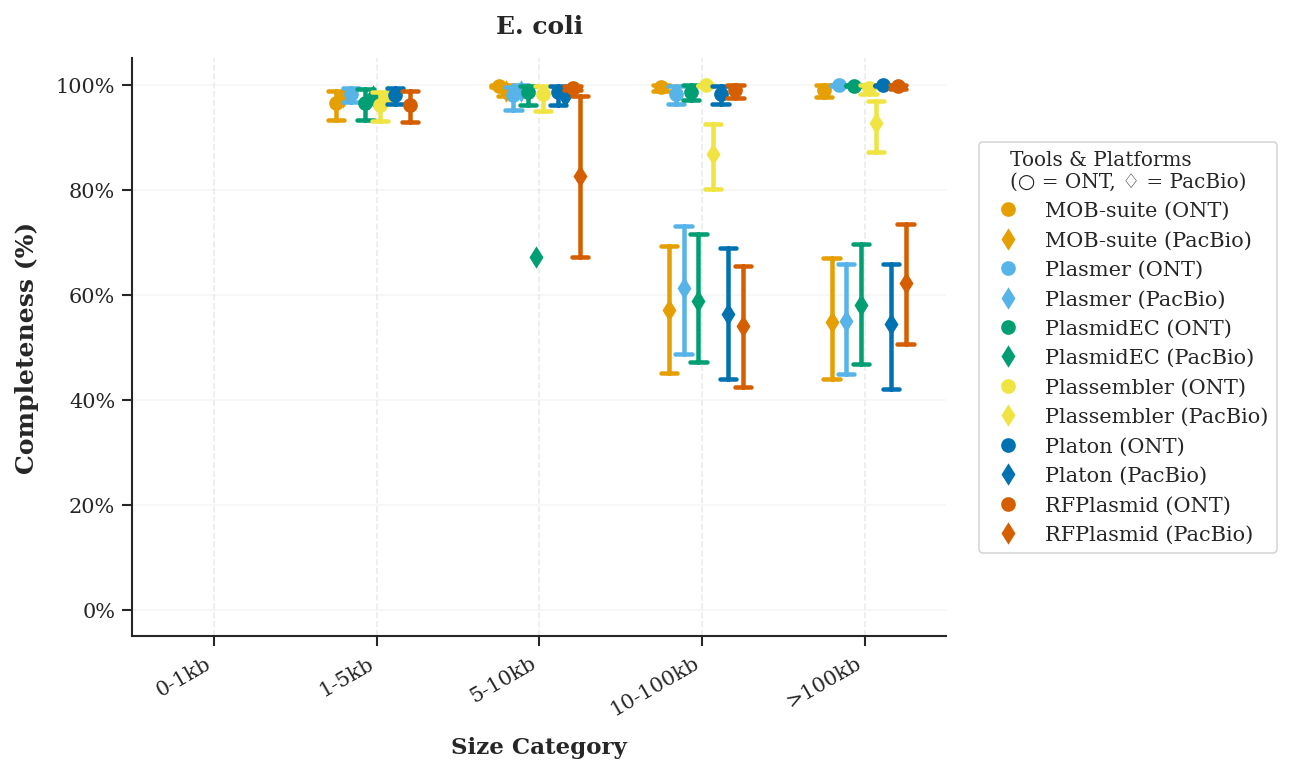

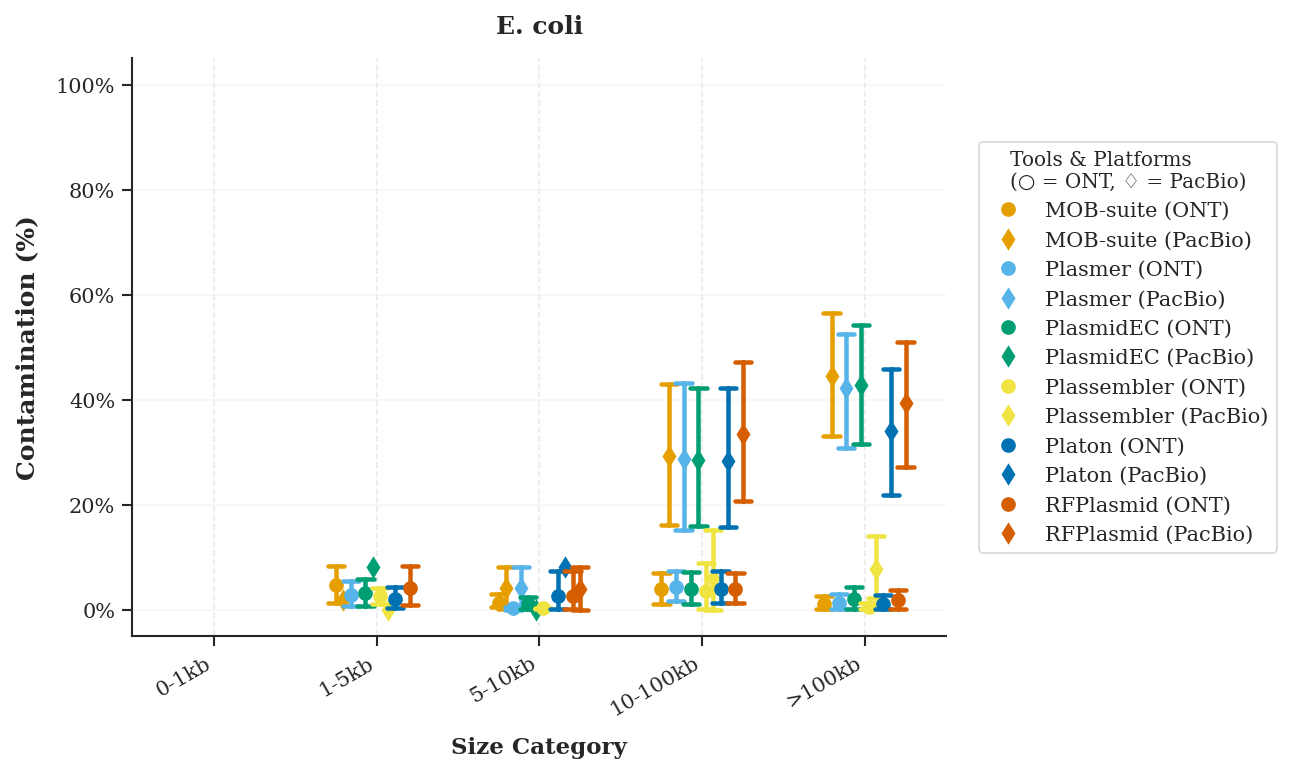

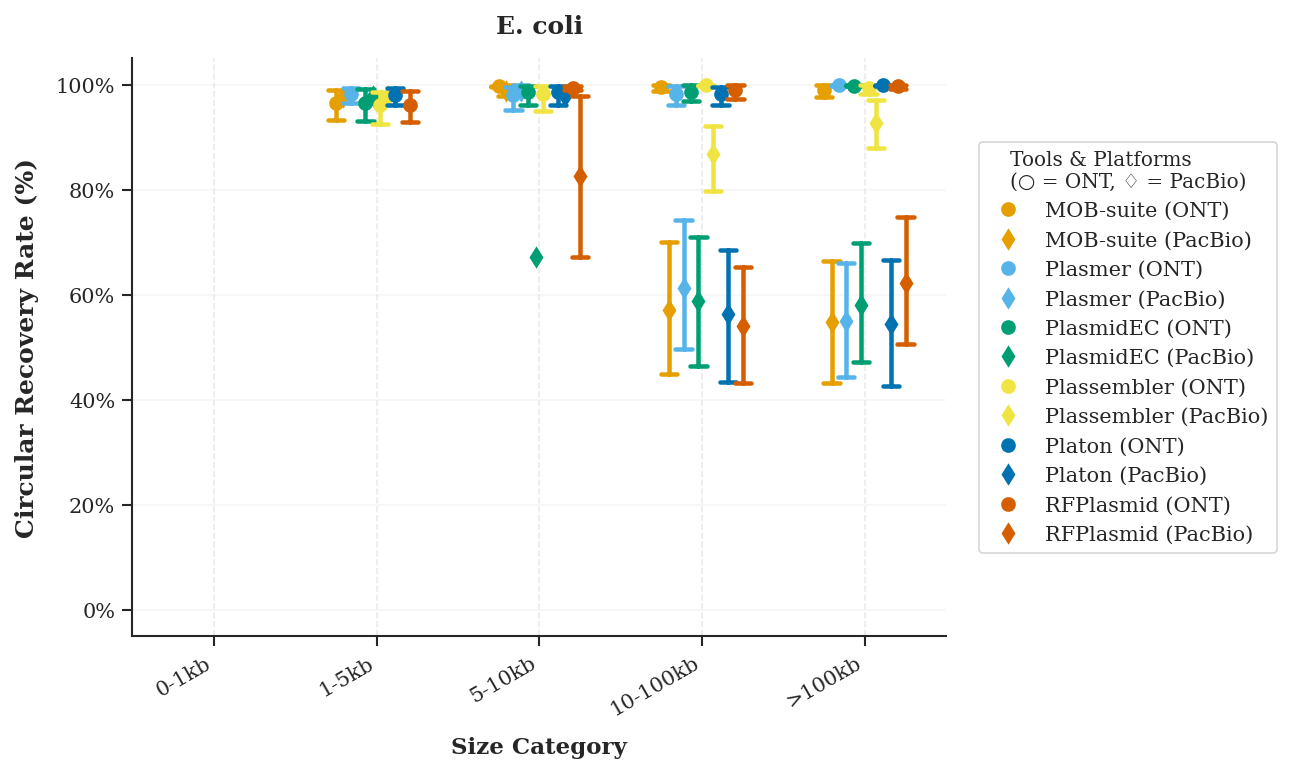

In [19]:
# --- Figure 6: Size category dependence -------------------------------

# Set publication style criteria
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update(
    {
        "font.family": "serif",
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

# Loop to generate an independent single-species plot file per metric
for metric_col, metric_label in METRICS_MAPPING:

    # Create single panel figure for E. coli
    fig, ax = plt.subplots(figsize=(7, 5))

    # Filter for E. coli and valid size groups
    sub_df = df[(df["Species"] == "ecoli") & (df["Size_Category"].isin(SIZE_ORDER))].copy()

    # Enforce scale normalization (0-1 -> 0-100) on target metrics
    if metric_col in SCALE_0_TO_1_METRICS:
        sub_df[metric_col] = sub_df[metric_col] * 100.0

    # Enforce exact sorting sequence on X-axis categories
    sub_df["Size_Category"] = pd.Categorical(
        sub_df["Size_Category"], categories=SIZE_ORDER, ordered=True
    )

    # Combine Tool and Platform for grouping
    sub_df["Tool_Platform"] = (
        sub_df["Tool"].astype(str) + " (" + sub_df["Platform"].astype(str) + ")"
    )

    # Build explicit hue orders, color codes, and marker styles
    hue_order = []
    palette_map = {}
    markers_map = {}

    for tool in TOOLS:
        for platform, marker_shape in [("ONT", "o"), ("PacBio", "d")]:
            combination_name = f"{tool} ({platform})"
            hue_order.append(combination_name)
            palette_map[combination_name] = TOOL_COLORS[tool]
            markers_map[combination_name] = marker_shape

    # Plot point ranges cleanly
    sns.pointplot(
        data=sub_df,
        x="Size_Category",
        y=metric_col,
        hue="Tool_Platform",
        hue_order=hue_order,
        palette=palette_map,
        markers=[markers_map[h] for h in hue_order],
        dodge=0.5,        # Vertical separation to keep tool comparisons clean
        join=False,       # Suppresses lines between size groups
        errorbar="ci",    # Renders vertical confidence interval whiskers
        capsize=0.1,      # Adds structural caps to whiskers
        ax=ax,
    )

    # Labels, layout limits, and Y percentage formatting
    ax.set_ylim(-5, 105)
    ax.set_title("E. coli", weight="bold", fontsize=12, pad=12)

    # Grid fine-tuning
    ax.grid(axis="x", linestyle="--", alpha=0.4, color="#cccccc", zorder=0)
    ax.grid(axis="y", linestyle="-", alpha=0.3, color="#e0e0e0", zorder=0)

    # Axis labels and formatting
    ax.set_ylabel(metric_label, weight="bold", labelpad=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, p: f"{int(val)}%"))

    # X-tick formatting
    ax.set_xticks(range(len(SIZE_ORDER)))
    ax.set_xticklabels(SIZE_ORDER, rotation=30, ha="right")
    ax.set_xlabel("Size Category", weight="bold", fontsize=11, labelpad=8)

    # Polish outer borders
    sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

    # Move legend outside right boundary
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(
        handles=handles,
        labels=labels,
        title="Tools & Platforms\n(○ = ONT, ♢ = PacBio)",
        loc="center left",
        bbox_to_anchor=(1.04, 0.5),
        frameon=True,
        borderaxespad=0,
    )

    # Save outputs safely
    fname = metric_col.lower().replace("_pct", "").replace("_", "")
    plt.savefig(
        f"{OUTPUT_DIR}/fig6_size_dependence_ecoli_{fname}.png", dpi=300, bbox_inches="tight"
    )
    plt.savefig(
        f"{OUTPUT_DIR}/fig6_size_dependence_ecoli_{fname}.pdf", bbox_inches="tight"
    )
    plt.show()


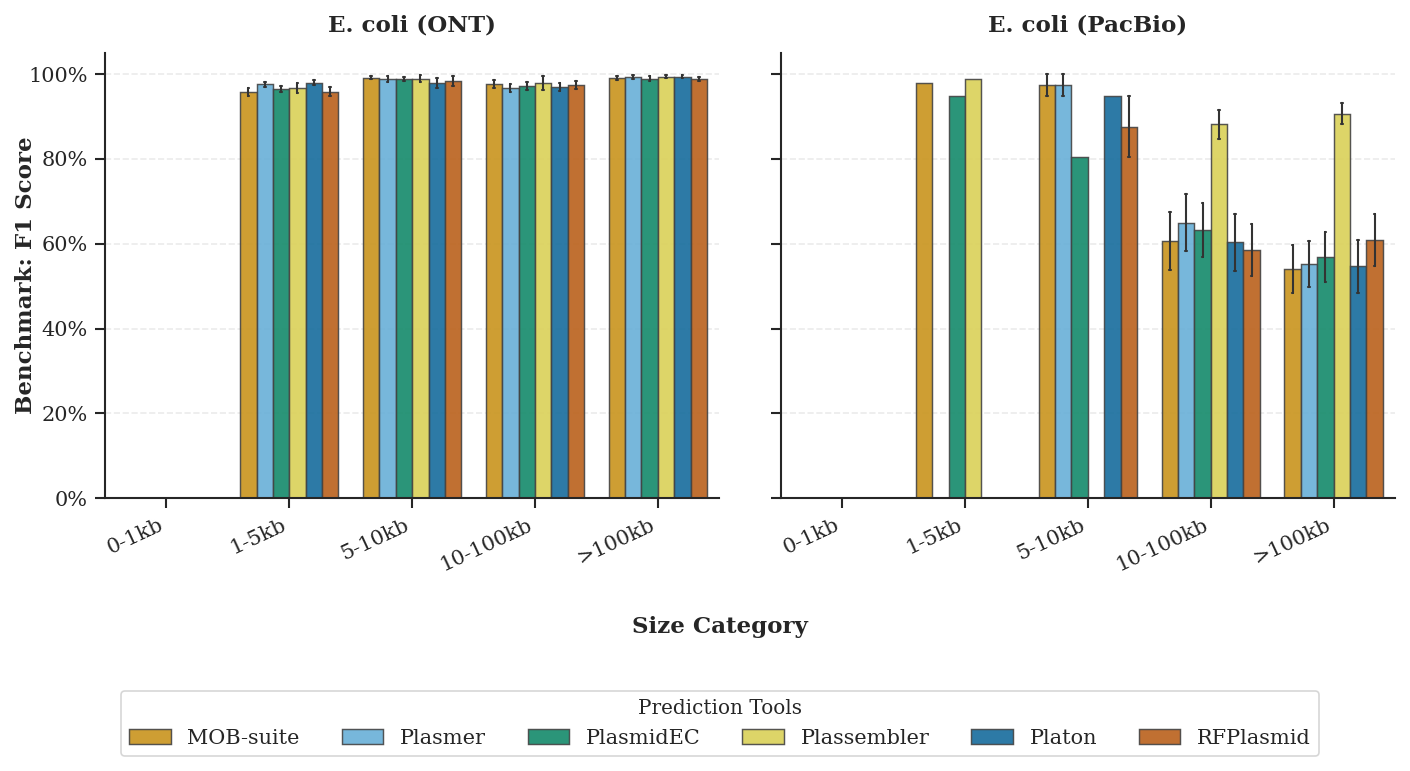

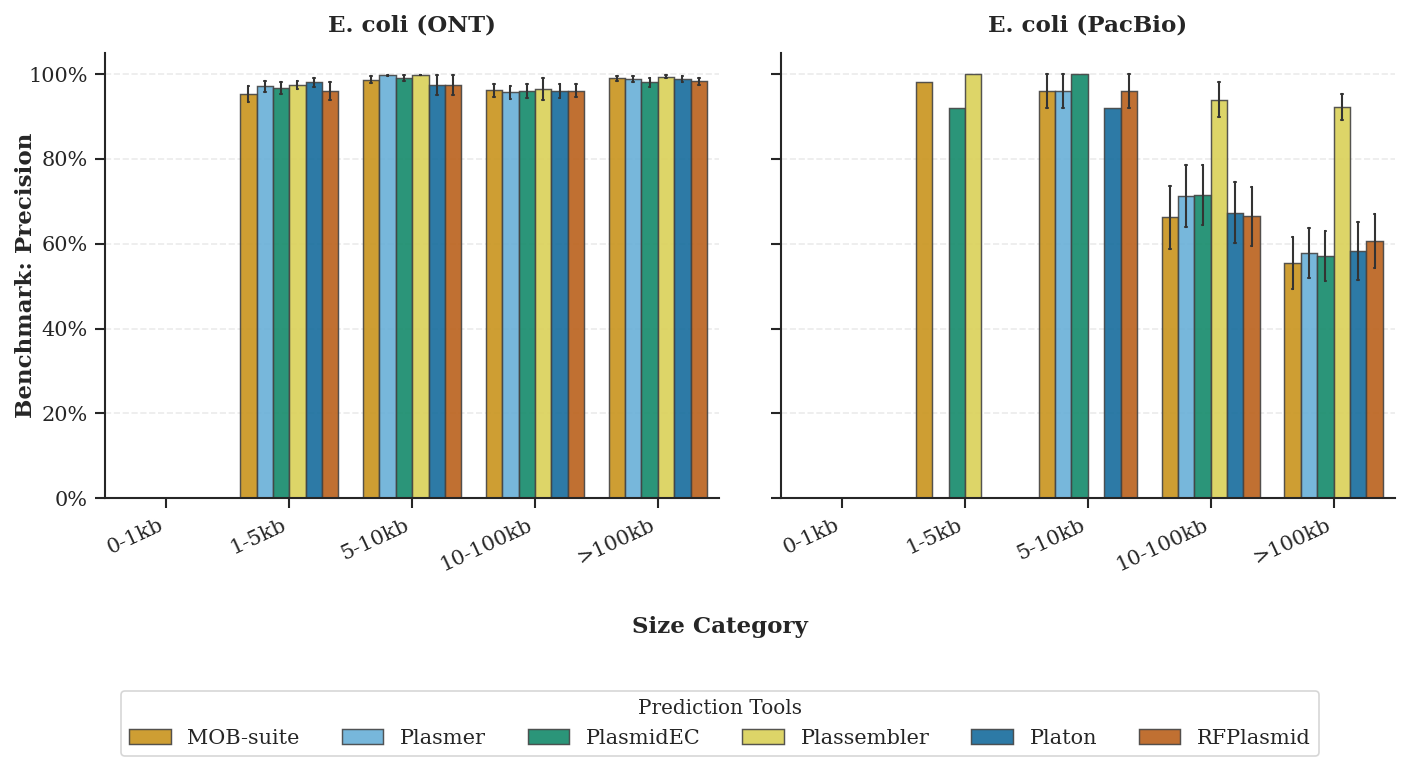

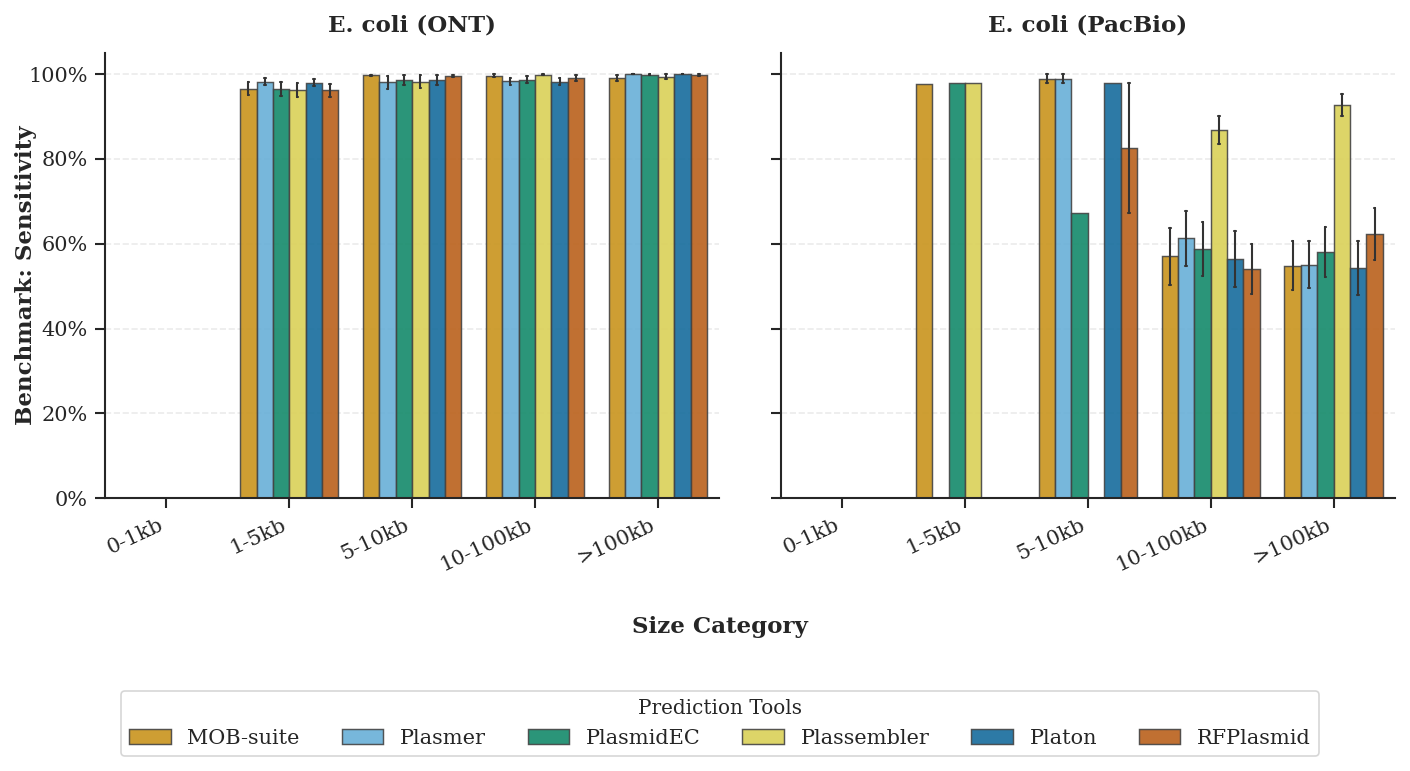

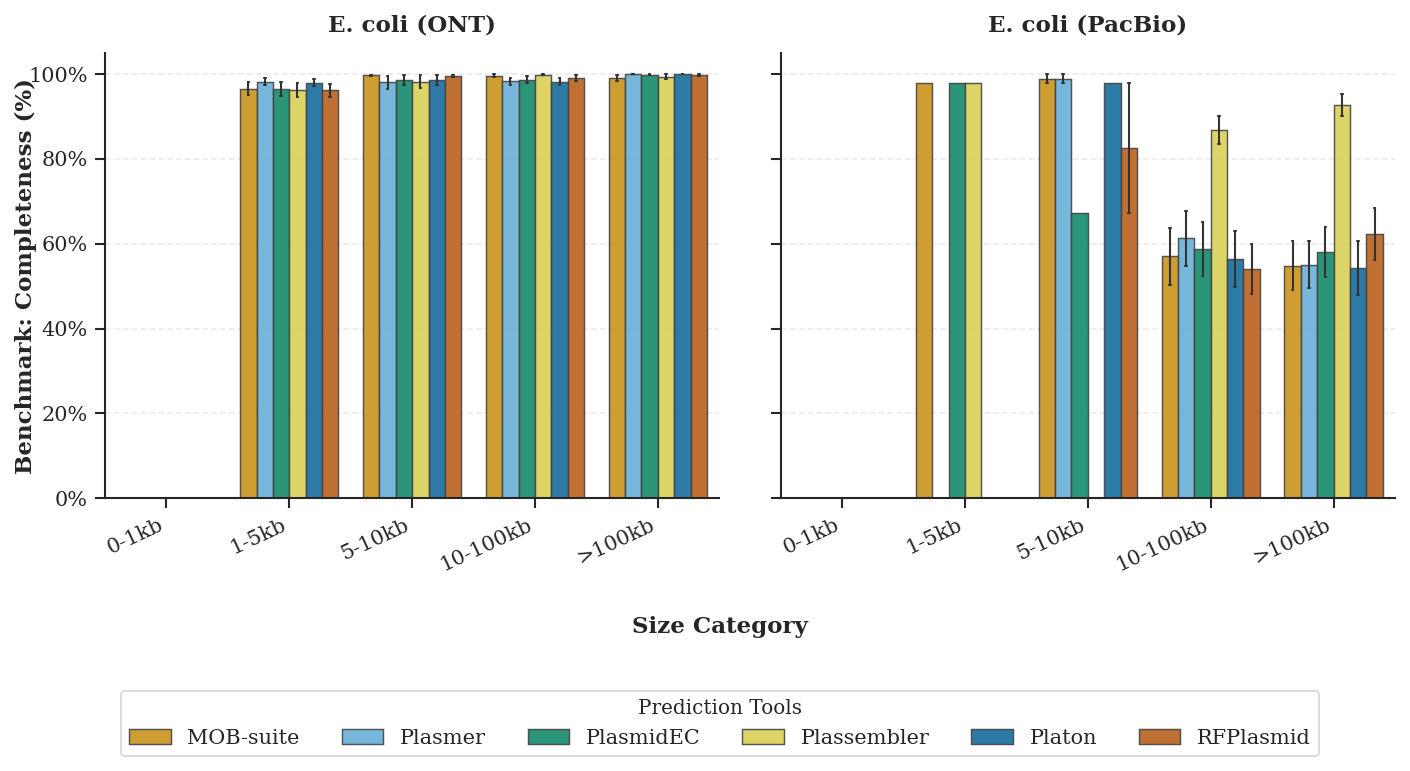

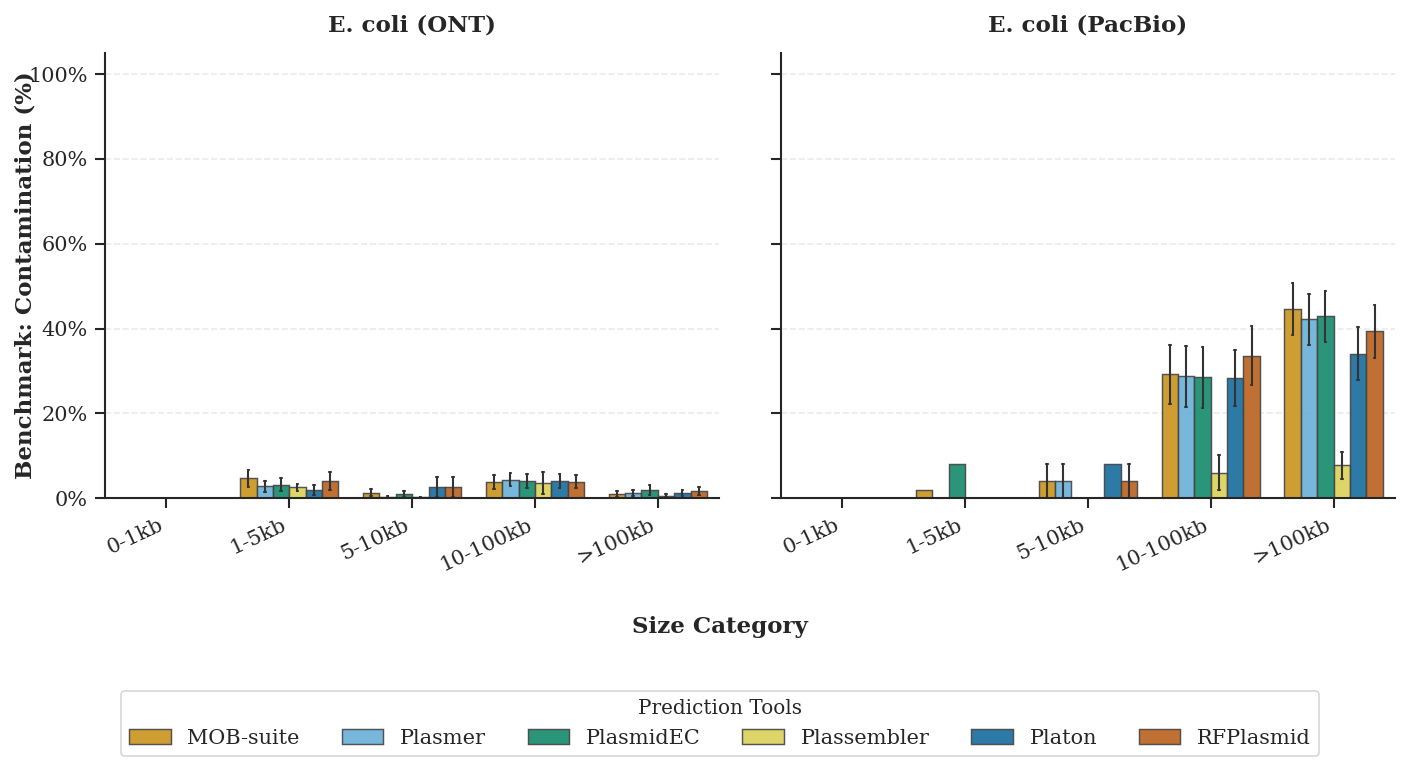

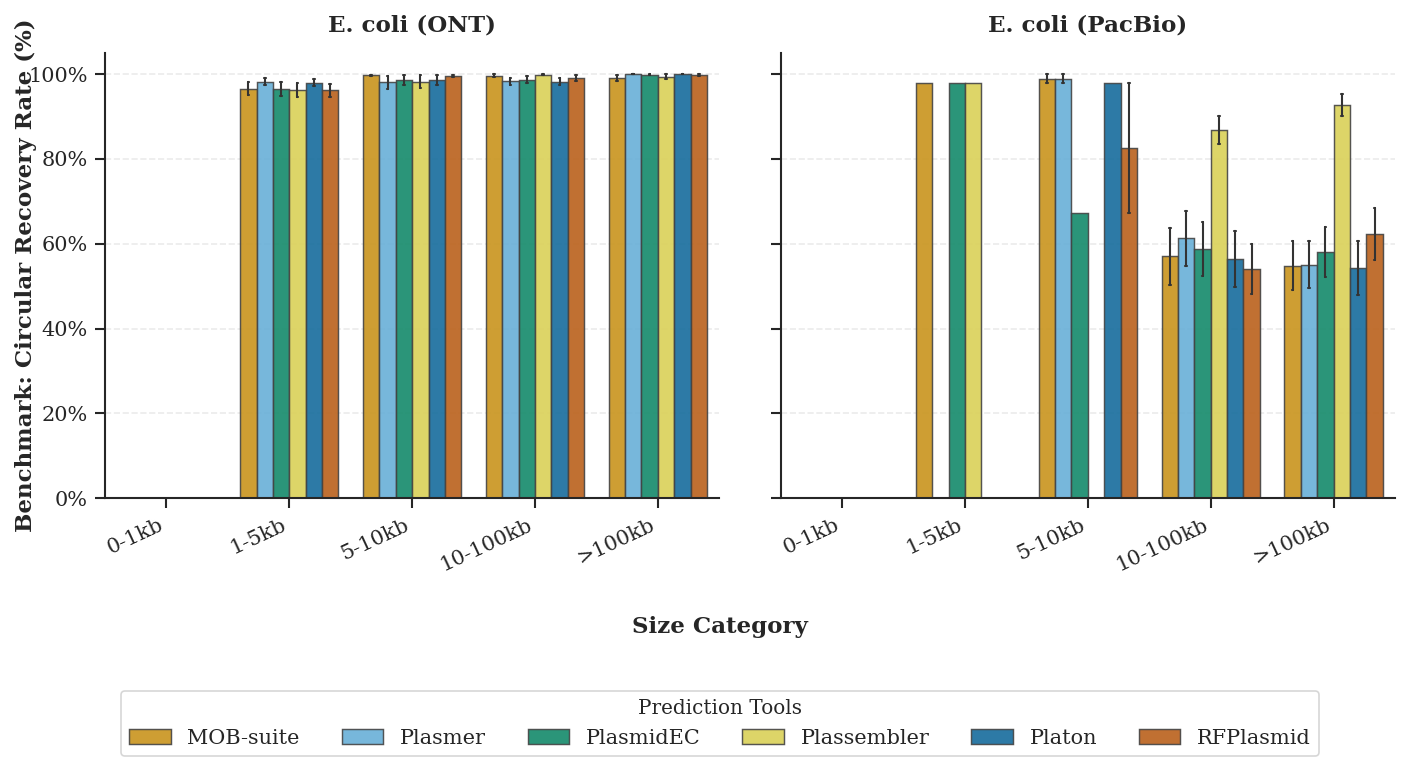

In [20]:
# --- Figure 7: Size-category stratified platform comparison ----------------

# Configure premium academic styling
sns.set_theme(style="ticks", context="paper")
plt.rcParams.update({
    "font.family": "serif",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "axes.titlesize": 11
})

for metric_col, metric_label in METRICS_MAPPING:

    # Initialize a 1x2 panel layout (Left: ONT, Right: PacBio)
    fig, axes = plt.subplots(
        1, 2, figsize=(10, 4.5), sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.1}
    )
    
    platforms = ["ONT", "PacBio"]

    for idx, pf in enumerate(platforms):
        ax = axes[idx]

        # Filter data strictly for E. coli, current platform, and size categories
        sub_df = df[
            (df["Species"] == "ecoli") & 
            (df["Platform"] == pf) & 
            (df["Size_Category"].isin(SIZE_ORDER))
        ].copy()

        # Enforce 0-1 to 0-100% normalization for target metrics
        if metric_col in SCALE_0_TO_1_METRICS:
            sub_df[metric_col] = sub_df[metric_col] * 100.0

        # Enforce exact categorical sorting sequence
        sub_df["Size_Category"] = pd.Categorical(
            sub_df["Size_Category"], categories=SIZE_ORDER, ordered=True
        )

        # Draw a grouped bar chart
        sns.barplot(
            data=sub_df,
            x="Size_Category",
            y=metric_col,
            hue="Tool",
            hue_order=TOOLS,
            palette=TOOL_COLORS,
            errorbar="se",        # Standard Error bars
            capsize=0.08,        # Clean structural caps on error whiskers
            err_kws={"linewidth": 1.0, "color": "#333333"},
            edgecolor="#444444", # Crisp bar borders
            linewidth=0.7,
            alpha=0.9,
            ax=ax
        )

        # Panel limits and background grid
        ax.set_ylim(0, 105)
        ax.grid(axis="y", linestyle="--", alpha=0.4, color="#cccccc", zorder=0)
        ax.set_xlabel("")
        ax.set_ylabel("")

        # Subplot headers displaying Platform
        ax.set_title(f"E. coli ({pf})", weight="bold", pad=10)

        # Left panel Y-axis percentage formatting
        if idx == 0:
            ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, p: f"{int(val)}%"))

        # Format X-ticks
        ax.set_xticks(range(len(SIZE_ORDER)))
        ax.set_xticklabels(SIZE_ORDER, rotation=25, ha="right")

        # Clear top and right borders
        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)
        
        # Wipe individual subplot legend instances
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    # Global shared axis labels
    fig.text(0.5, 0.02, "Size Category", ha="center", weight="bold", fontsize=11)
    fig.text(0.03, 0.55, f"Benchmark: {metric_label}", va="center", rotation=90, weight="bold", fontsize=11)

    # Place a single global legend horizontally at the bottom
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles=handles,
        labels=labels,
        title="Prediction Tools",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.05),
        ncol=len(TOOLS),  # Dynamic horizontal alignment based on number of tools
        frameon=True,
        facecolor="white",
        edgecolor="#cccccc"
    )

    # Adjust layout spacing
    plt.subplots_adjust(right=0.95, bottom=0.22, left=0.09, top=0.88)

    # Save to disk
    fname = metric_col.lower().replace("_pct", "").replace("_", "")
    plt.savefig(f"{OUTPUT_DIR}/fig7_barplot_ecoli_1x2_{fname}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{OUTPUT_DIR}/fig7_barplot_ecoli_1x2_{fname}.pdf", bbox_inches="tight")
    plt.show()


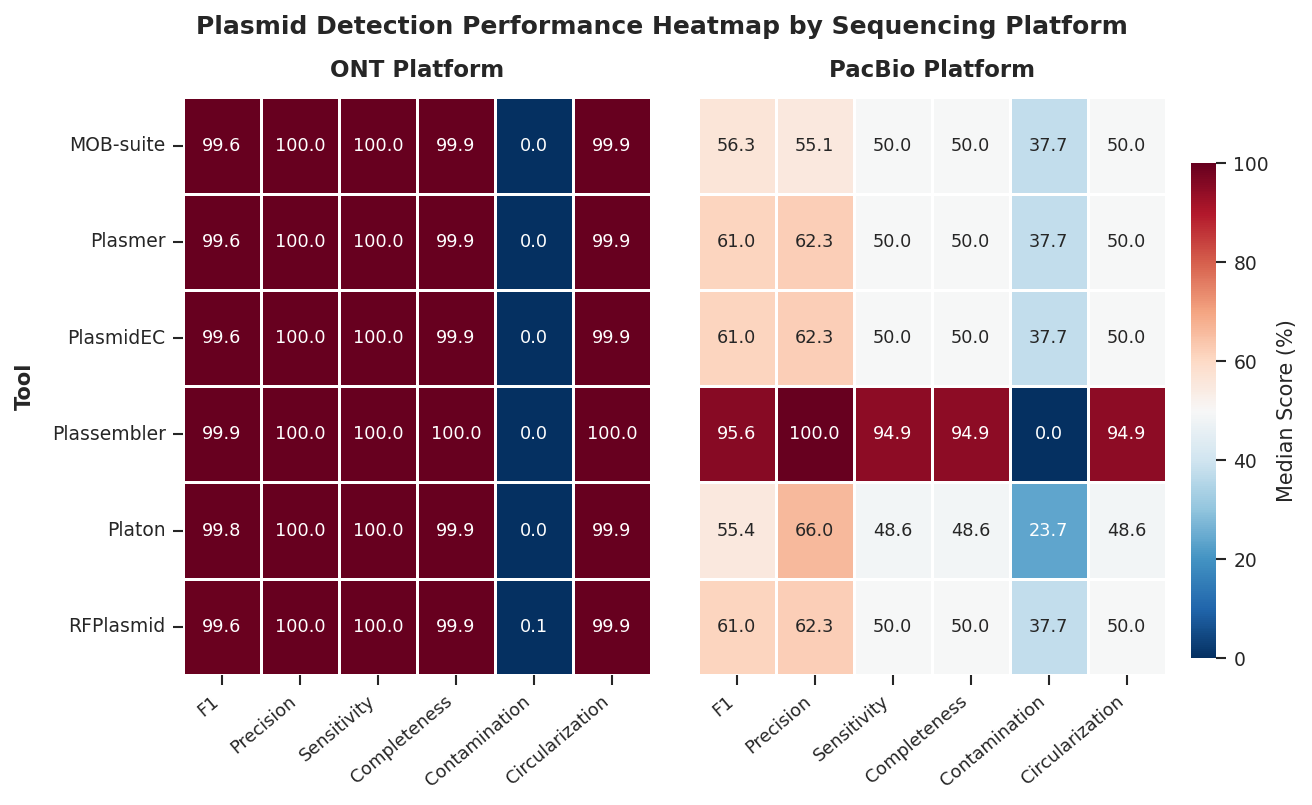

In [21]:
# --- Figure 8: Median performance heatmaps by platform -------------------------------

# Set publication typography and layout parameters
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 11,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 9,
    }
)

fig, axes = plt.subplots(
    1,
    len(PLATFORMS),
    figsize=(4.2 * len(PLATFORMS), 5.5),
    squeeze=False,
    sharey=True,  # Share Y-axis tool names cleanly across panels
)

# Shared Colorbar Axis setup (right side placement)
cbar_ax = fig.add_axes([0.92, 0.20, 0.02, 0.60])  # [left, bottom, width, height]

# Rename map for standardized display labels
RENAME_METRICS = {
    "F1_Score": "F1",
    "Precision": "Precision",
    "Sensitivity": "Sensitivity",
    "Mean_Completeness": "Completeness",
    "Contamination_Pct": "Contamination",
    "Circularization_Pct": "Circularization",
}

for idx, (ax, platform) in enumerate(zip(axes[0], PLATFORMS)):
    sub = df[df["Platform"] == platform].copy()

    # Compute median matrix
    med = (
        sub.groupby("Tool", observed=True)[METRICS]
        .median()
        .reindex(TOOLS)
    )

    # Scale 0-1 metrics to 0-100%
    for metric in SCALE_0_TO_1_METRICS:
        if metric in med.columns:
            med[metric] = med[metric] * 100.0

    med = med.rename(columns=RENAME_METRICS)

    # Plot single shared-colorbar heatmap
    sns.heatmap(
        med,
        annot=True,
        fmt=".1f",
        cmap="RdBu_r",
        vmin=0,
        vmax=100,
        linewidths=0.5,
        linecolor="white",
        square=False,
        cbar=(idx == 0),  # Instantiate colorbar object once
        cbar_ax=cbar_ax if idx == 0 else None,
        cbar_kws={"label": "Median Score (%)"} if idx == 0 else None,
        annot_kws={"size": 8.5},
        ax=ax,
    )

    # Format subplot header
    ax.set_title(f"{platform} Platform", fontweight="bold", pad=10)
    ax.set_xlabel("")
    
    # Hide Y-axis labels on subsequent right subplots to maximize data-ink ratio
    if idx == 0:
        ax.set_ylabel("Tool", fontweight="bold", labelpad=8)
    else:
        ax.set_ylabel("")
        ax.tick_params(left=False)

    # Rotate X-tick labels cleanly
    ax.set_xticklabels(ax.get_xticklabels(), rotation=40, ha="right")

# Figure title
fig.suptitle(
    "Plasmid Detection Performance Heatmap by Sequencing Platform",
    fontsize=12,
    fontweight="bold",
    y=0.98,
)

# Custom spacing adjustment to leave room for the title and single colorbar
plt.subplots_adjust(left=0.12, right=0.90, top=0.88, bottom=0.18, wspace=0.10)

# Save publication-ready vector and raster formats
plt.savefig(
    f"{OUTPUT_DIR}/fig8_ecoli_platform_median_heatmap.png", dpi=300, bbox_inches="tight"
)
plt.savefig(
    f"{OUTPUT_DIR}/fig8_ecoli_platform_median_heatmap.pdf", bbox_inches="tight"
)
plt.show()


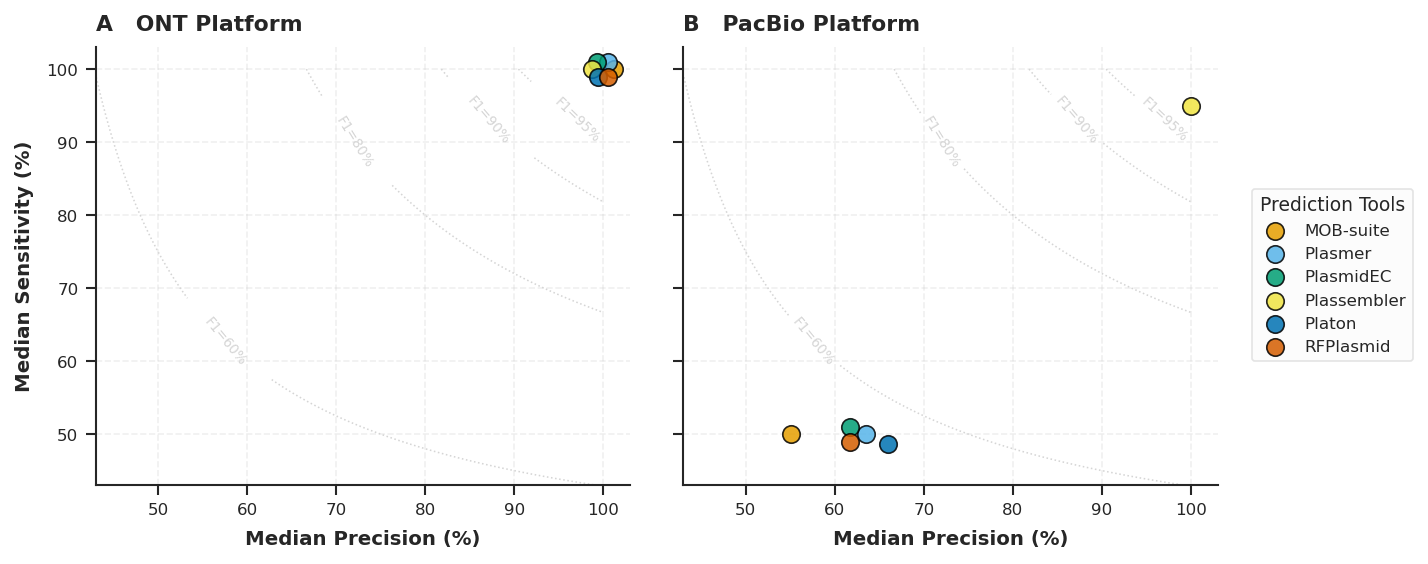

In [22]:
# --- Figure 9: Precision-Recall Trade-off ------------------------------------------

# Set publication-grade typography and global style
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

# 1. Prepare Data
summary_pr = (
    df[df["Species"].astype(str).str.contains("coli", case=False, na=False)]
    .groupby(["Tool", "Platform"], observed=True)[
        ["Precision", "Sensitivity", "F1_Score"]
    ]
    .median()
    .reset_index()
)

summary_pr["Precision_pct"] = summary_pr["Precision"] * 100.0
summary_pr["Sensitivity_pct"] = summary_pr["Sensitivity"] * 100.0

# 2. Setup 1x2 Subplot Grid
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.0), sharex=True, sharey=True)

platforms = ["ONT", "PacBio"]
panel_tags = ["A", "B"]

# 3. Iso-F1 curves mesh definition
x = np.linspace(1, 100, 300)
y = np.linspace(1, 100, 300)
X, Y = np.meshgrid(x, y)
F1 = 2 * (X * Y) / (X + Y)

# Manual label positions [(Precision_x, Sensitivity_y)] to prevent border clipping
label_positions = [(58, 63), (72, 90), (87, 93), (97, 93)]

for idx, pf in enumerate(platforms):
    ax = axes[idx]

    # Draw Iso-F1 background contour lines
    cs = ax.contour(
        X,
        Y,
        F1,
        levels=[60, 80, 90, 95],
        colors="#d5d5d5",
        linestyles=":",
        linewidths=0.75,
        zorder=1,
    )

    # Clean inline contour labels positioned safely inside the plot area
    ax.clabel(
        cs,
        inline=True,
        fontsize=6.5,
        fmt="F1=%.0f%%",
        manual=label_positions,
    )

    # Filter data per platform
    sub = summary_pr[summary_pr["Platform"] == pf].copy()

    # --- RESOLVE DATA OCCLUSION VIA RADIAL JITTER ---
    sub["pos_key"] = (
        sub["Precision_pct"].round(1).astype(str)
        + "_"
        + sub["Sensitivity_pct"].round(1).astype(str)
    )

    for pos_key, group in sub.groupby("pos_key"):
        n_points = len(group)
        if n_points > 1:
            # Apply slight spiral displacement for perfectly overlapping points
            angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
            radius = 1.2  # Small percentage shift in data coordinates
            dx = radius * np.cos(angles)
            dy = radius * np.sin(angles)
            sub.loc[group.index, "x_plot"] = group["Precision_pct"] + dx
            sub.loc[group.index, "y_plot"] = group["Sensitivity_pct"] + dy
        else:
            sub.loc[group.index, "x_plot"] = group["Precision_pct"]
            sub.loc[group.index, "y_plot"] = group["Sensitivity_pct"]

    # Plot Scatter points with subtle transparency and crisp borders
    for _, row in sub.iterrows():
        tool_name = row["Tool"]

        ax.scatter(
            row["x_plot"],
            row["y_plot"],
            s=70,
            color=TOOL_COLORS.get(tool_name, "#333333"),
            edgecolor="black",
            linewidth=0.8,
            alpha=0.85,
            zorder=3,
            label=tool_name,
        )

    # Grid & Axis limits (43% bound provides sufficient margin for labels)
    ax.set_xlim(43, 103)
    ax.set_ylim(43, 103)
    ax.grid(True, linestyle="--", alpha=0.3, color="#cccccc", zorder=0)

    # Clean Panel Titles & Header Alignments
    ax.set_title(
        f"{panel_tags[idx]}   {pf} Platform",
        loc="left",
        fontweight="bold",
        fontsize=10.5,
        pad=8,
    )

    ax.set_xlabel("Median Precision (%)", fontweight="bold", labelpad=6)
    if idx == 0:
        ax.set_ylabel("Median Sensitivity (%)", fontweight="bold", labelpad=6)
    else:
        ax.set_ylabel("")

    sns.despine(ax=ax)

# 4. Global Legend Construction
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

fig.legend(
    by_label.values(),
    by_label.keys(),
    title="Prediction Tools",
    title_fontsize=9,
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8,
)

# 5. Canvas Padding Adjustment
plt.subplots_adjust(left=0.08, right=0.96, top=0.88, bottom=0.15, wspace=0.10)

# 6. Save High-DPI Publication Assets
plt.savefig(
    f"{OUTPUT_DIR}/fig9_ecoli_precision_sensitivity_tradeoff_final.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    f"{OUTPUT_DIR}/fig9_ecoli_precision_sensitivity_tradeoff_final.pdf",
    bbox_inches="tight",
)
plt.show()


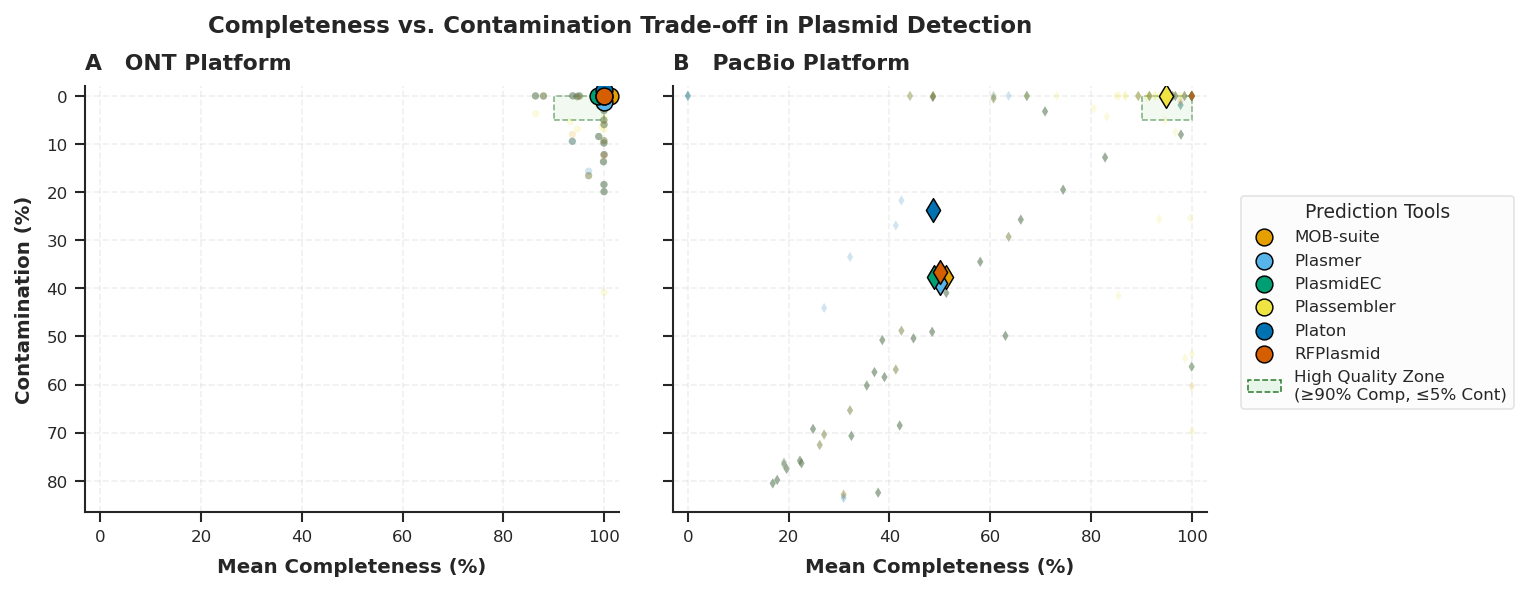

In [23]:
# --- Figure 10: Completeness vs Contamination Trade-off ----------------------------------------

# Configure publication-grade styling
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    }
)

# 1. Data Cleaning & Preparation
trade = df[
    [
        "Tool",
        "Platform",
        "Sample",
        "Mean_Completeness",
        "Contamination_Pct",
        "F1_Score",
    ]
].dropna().copy()

# Enforce 0-100% scale for completeness
if trade["Mean_Completeness"].max() <= 1.0:
    trade["Mean_Completeness"] = trade["Mean_Completeness"] * 100.0

# 2. Setup Canvas
fig, axes = plt.subplots(1, 2, figsize=(8.5, 4.0), sharex=True, sharey=True)

platforms = ["ONT", "PacBio"]
panel_tags = ["A", "B"]
markers = {"ONT": "o", "PacBio": "d"}

y_max = max(50, trade["Contamination_Pct"].max() + 3)

for idx, platform in enumerate(platforms):
    ax = axes[idx]

    # --- High Quality Target Zone (Adjusted for Inverted Y-Axis) ---
    # Origin at y=5 with height=-5 ensures patch covers 0% to 5% contamination top-down
    hq_rect = patches.Rectangle(
        (90, 5),
        10,
        -5,
        linewidth=0.75,
        edgecolor="#2e7d32",
        facecolor="#e8f5e9",
        alpha=0.6,
        zorder=0,
        linestyle="--",
    )
    ax.add_patch(hq_rect)

    # Filter data for current platform
    sub_df = trade[trade["Platform"] == platform].copy()

    # Calculate Tool Medians
    medians = (
        sub_df.groupby("Tool", observed=True)[
            ["Mean_Completeness", "Contamination_Pct"]
        ]
        .median()
        .reset_index()
    )

    # --- RESOLVE MEDIAN POINT OCCLUSION VIA RADIAL JITTER ---
    medians["pos_key"] = (
        medians["Mean_Completeness"].round(1).astype(str)
        + "_"
        + medians["Contamination_Pct"].round(1).astype(str)
    )

    for pos_key, group in medians.groupby("pos_key"):
        n_points = len(group)
        if n_points > 1:
            angles = np.linspace(0, 2 * np.pi, n_points, endpoint=False)
            radius = 1.2
            dx = radius * np.cos(angles)
            dy = radius * np.sin(angles)
            medians.loc[group.index, "x_plot"] = group["Mean_Completeness"] + dx
            medians.loc[group.index, "y_plot"] = group["Contamination_Pct"] + dy
        else:
            medians.loc[group.index, "x_plot"] = group["Mean_Completeness"]
            medians.loc[group.index, "y_plot"] = group["Contamination_Pct"]

    # 3. Plot Raw Points & Overlay Tool Medians
    for tool_name, group in sub_df.groupby("Tool"):
        color = TOOL_COLORS.get(tool_name, "#333333")
        marker = markers[platform]

        # Raw sample distribution points
        ax.scatter(
            group["Mean_Completeness"],
            group["Contamination_Pct"],
            s=12,
            alpha=0.18,
            color=color,
            marker=marker,
            edgecolor="none",
            zorder=2,
        )

    # Overlay Medians
    for _, m_row in medians.iterrows():
        tool_name = m_row["Tool"]
        color = TOOL_COLORS.get(tool_name, "#333333")
        marker = markers[platform]

        ax.scatter(
            m_row["x_plot"],
            m_row["y_plot"],
            s=65,
            color=color,
            marker=marker,
            edgecolor="black",
            linewidth=0.7,
            zorder=4,
            label=tool_name,
        )

    # 4. Axis Limits & Formatting
    ax.set_xlim(-3, 103)
    ax.set_ylim(-2, y_max)
    ax.set_xlabel("Mean Completeness (%)", fontweight="bold", labelpad=6)
    ax.grid(True, linestyle="--", alpha=0.3, color="#cccccc", zorder=0)

    # Clean Panel Titles
    ax.set_title(
        f"{panel_tags[idx]}   {platform} Platform",
        loc="left",
        fontweight="bold",
        fontsize=10.5,
        pad=8,
    )

    sns.despine(ax=ax)

# Y-Axis Formatting (Left Subplot Only)
axes[0].set_ylabel("Contamination (%)", fontweight="bold", labelpad=6)
axes[0].invert_yaxis()

# 5. Global Unified Legend Construction
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))

target_patch = patches.Patch(
    facecolor="#e8f5e9",
    edgecolor="#2e7d32",
    linestyle="--",
    linewidth=0.75,
    label="High Quality Zone\n(≥90% Comp, ≤5% Cont)",
)

legend_handles = list(by_label.values()) + [target_patch]
legend_labels = list(by_label.keys()) + [target_patch.get_label()]

fig.legend(
    legend_handles,
    legend_labels,
    title="Prediction Tools",
    title_fontsize=9,
    bbox_to_anchor=(0.98, 0.5),
    loc="center left",
    frameon=True,
    facecolor="#fcfcfc",
    edgecolor="#dddddd",
    fontsize=8,
)

# Figure Title
fig.suptitle(
    "Completeness vs. Contamination Trade-off in Plasmid Detection",
    fontsize=11,
    fontweight="bold",
    y=0.98,
)

# Layout Spacing
plt.subplots_adjust(left=0.08, right=0.96, top=0.86, bottom=0.15, wspace=0.10)

# 6. Save Publication Outputs
plt.savefig(
    f"{OUTPUT_DIR}/fig10_ecoli_completeness_contamination_clean.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    f"{OUTPUT_DIR}/fig10_ecoli_completeness_contamination_clean.pdf",
    bbox_inches="tight",
)
plt.show()


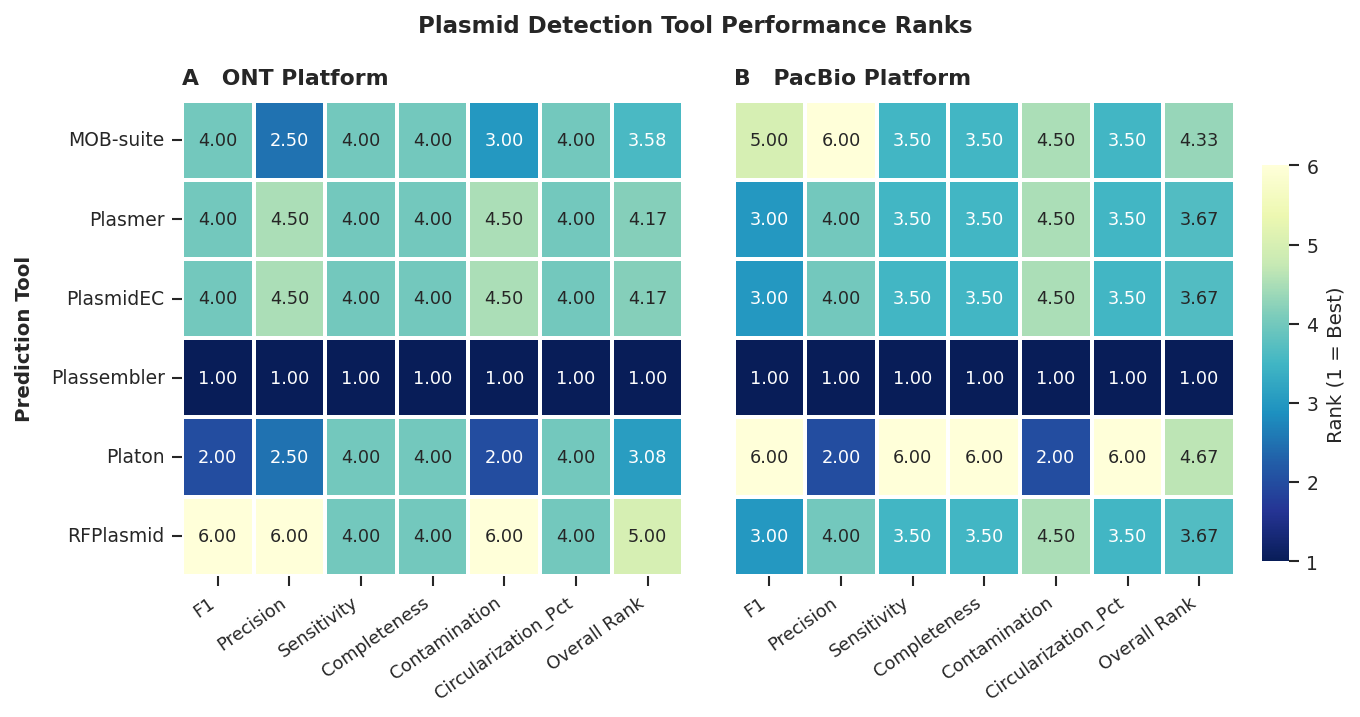

In [24]:
# --- Figure 11: Tool Rank Heatmap Matrix ------------------

# Set publication-grade styling
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8.5,
        "axes.labelsize": 9.5,
        "axes.titlesize": 10,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 9,
    }
)

# Metric Labels
metric_labels = {
    "F1_Score": "F1",
    "Precision": "Precision",
    "Sensitivity": "Sensitivity",
    "Mean_Completeness": "Completeness",
    "Contamination_Pct": "Contamination",
    "Overall_Mean_Rank": "Overall Rank",
}

rank_rows = []

for platform in PLATFORMS:
    summary = (
        df[df["Platform"] == platform]
        .groupby("Tool", observed=True)[METRICS]
        .median()
        .reindex(TOOLS)
    )

    ranks = pd.DataFrame(index=summary.index)

    for metric in METRICS:
        # Rank 1 = Best performance.
        # Higher is better for F1/Precision/Sensitivity/Completeness.
        # Lower is better for Contamination.
        lower_is_better = metric == "Contamination_Pct"
        ranks[metric] = summary[metric].rank(
            ascending=lower_is_better, method="average"
        )

    ranks["Overall_Mean_Rank"] = ranks.mean(axis=1)

    temp = ranks.reset_index()
    temp["Platform"] = platform
    rank_rows.append(temp)

rank_df = pd.concat(rank_rows, ignore_index=True)

# Save ranked TSV report
rank_df.to_csv(f"{OUTPUT_DIR}/tool_ranks_ecoli.tsv", sep="\t", index=False)

# Setup Canvas Matrix (One panel per platform)
fig, axes = plt.subplots(
    1,
    len(PLATFORMS),
    figsize=(4.5 * len(PLATFORMS), 4.8),
    sharey=True,
)

if len(PLATFORMS) == 1:
    axes = [axes]

# Shared Colorbar Axis setup
cbar_ax = fig.add_axes([0.92, 0.22, 0.02, 0.55])

panel_tags = ["A", "B"]

for idx, platform in enumerate(PLATFORMS):
    ax = axes[idx]

    # Reshape matrix for current platform
    sub_rank = (
        rank_df[rank_df["Platform"] == platform]
        .set_index("Tool")[METRICS + ["Overall_Mean_Rank"]]
        .reindex(TOOLS)
        .rename(columns=metric_labels)
    )

    # Plot Matrix
    sns.heatmap(
        sub_rank,
        annot=True,
        fmt=".2f",
        cmap="YlGnBu_r",  # High-contrast sequential color scheme (Rank 1 = Darkest)
        vmin=1,
        vmax=len(TOOLS),
        linewidths=1.0,
        linecolor="white",
        square=False,
        cbar=(idx == 0),
        cbar_ax=cbar_ax if idx == 0 else None,
        cbar_kws={"label": "Rank (1 = Best)"} if idx == 0 else None,
        annot_kws={"size": 8.5, "weight": "medium"},
        ax=ax,
    )

    # Panel titles & tags
    ax.set_title(
        f"{panel_tags[idx]}   {platform} Platform",
        loc="left",
        fontweight="bold",
        fontsize=10.5,
        pad=8,
    )
    
    ax.set_xlabel("")
    
    # Hide repetitive Y-axis labels on internal subplots
    if idx == 0:
        ax.set_ylabel("Prediction Tool", fontweight="bold", labelpad=8)
    else:
        ax.set_ylabel("")
        ax.tick_params(left=False)

    # Rotate X-tick labels cleanly
    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")

# Main Title
fig.suptitle(
    "Plasmid Detection Tool Performance Ranks",
    fontsize=11,
    fontweight="bold",
    y=0.98,
)

# Adjust Subplot Margins
plt.subplots_adjust(left=0.12, right=0.90, top=0.86, bottom=0.20, wspace=0.10)

# Save High-DPI Publication Outputs
plt.savefig(
    f"{OUTPUT_DIR}/fig11_ecoli_tool_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    f"{OUTPUT_DIR}/fig11_ecoli_tool_rank_heatmap.pdf",
    bbox_inches="tight",
)
plt.show()


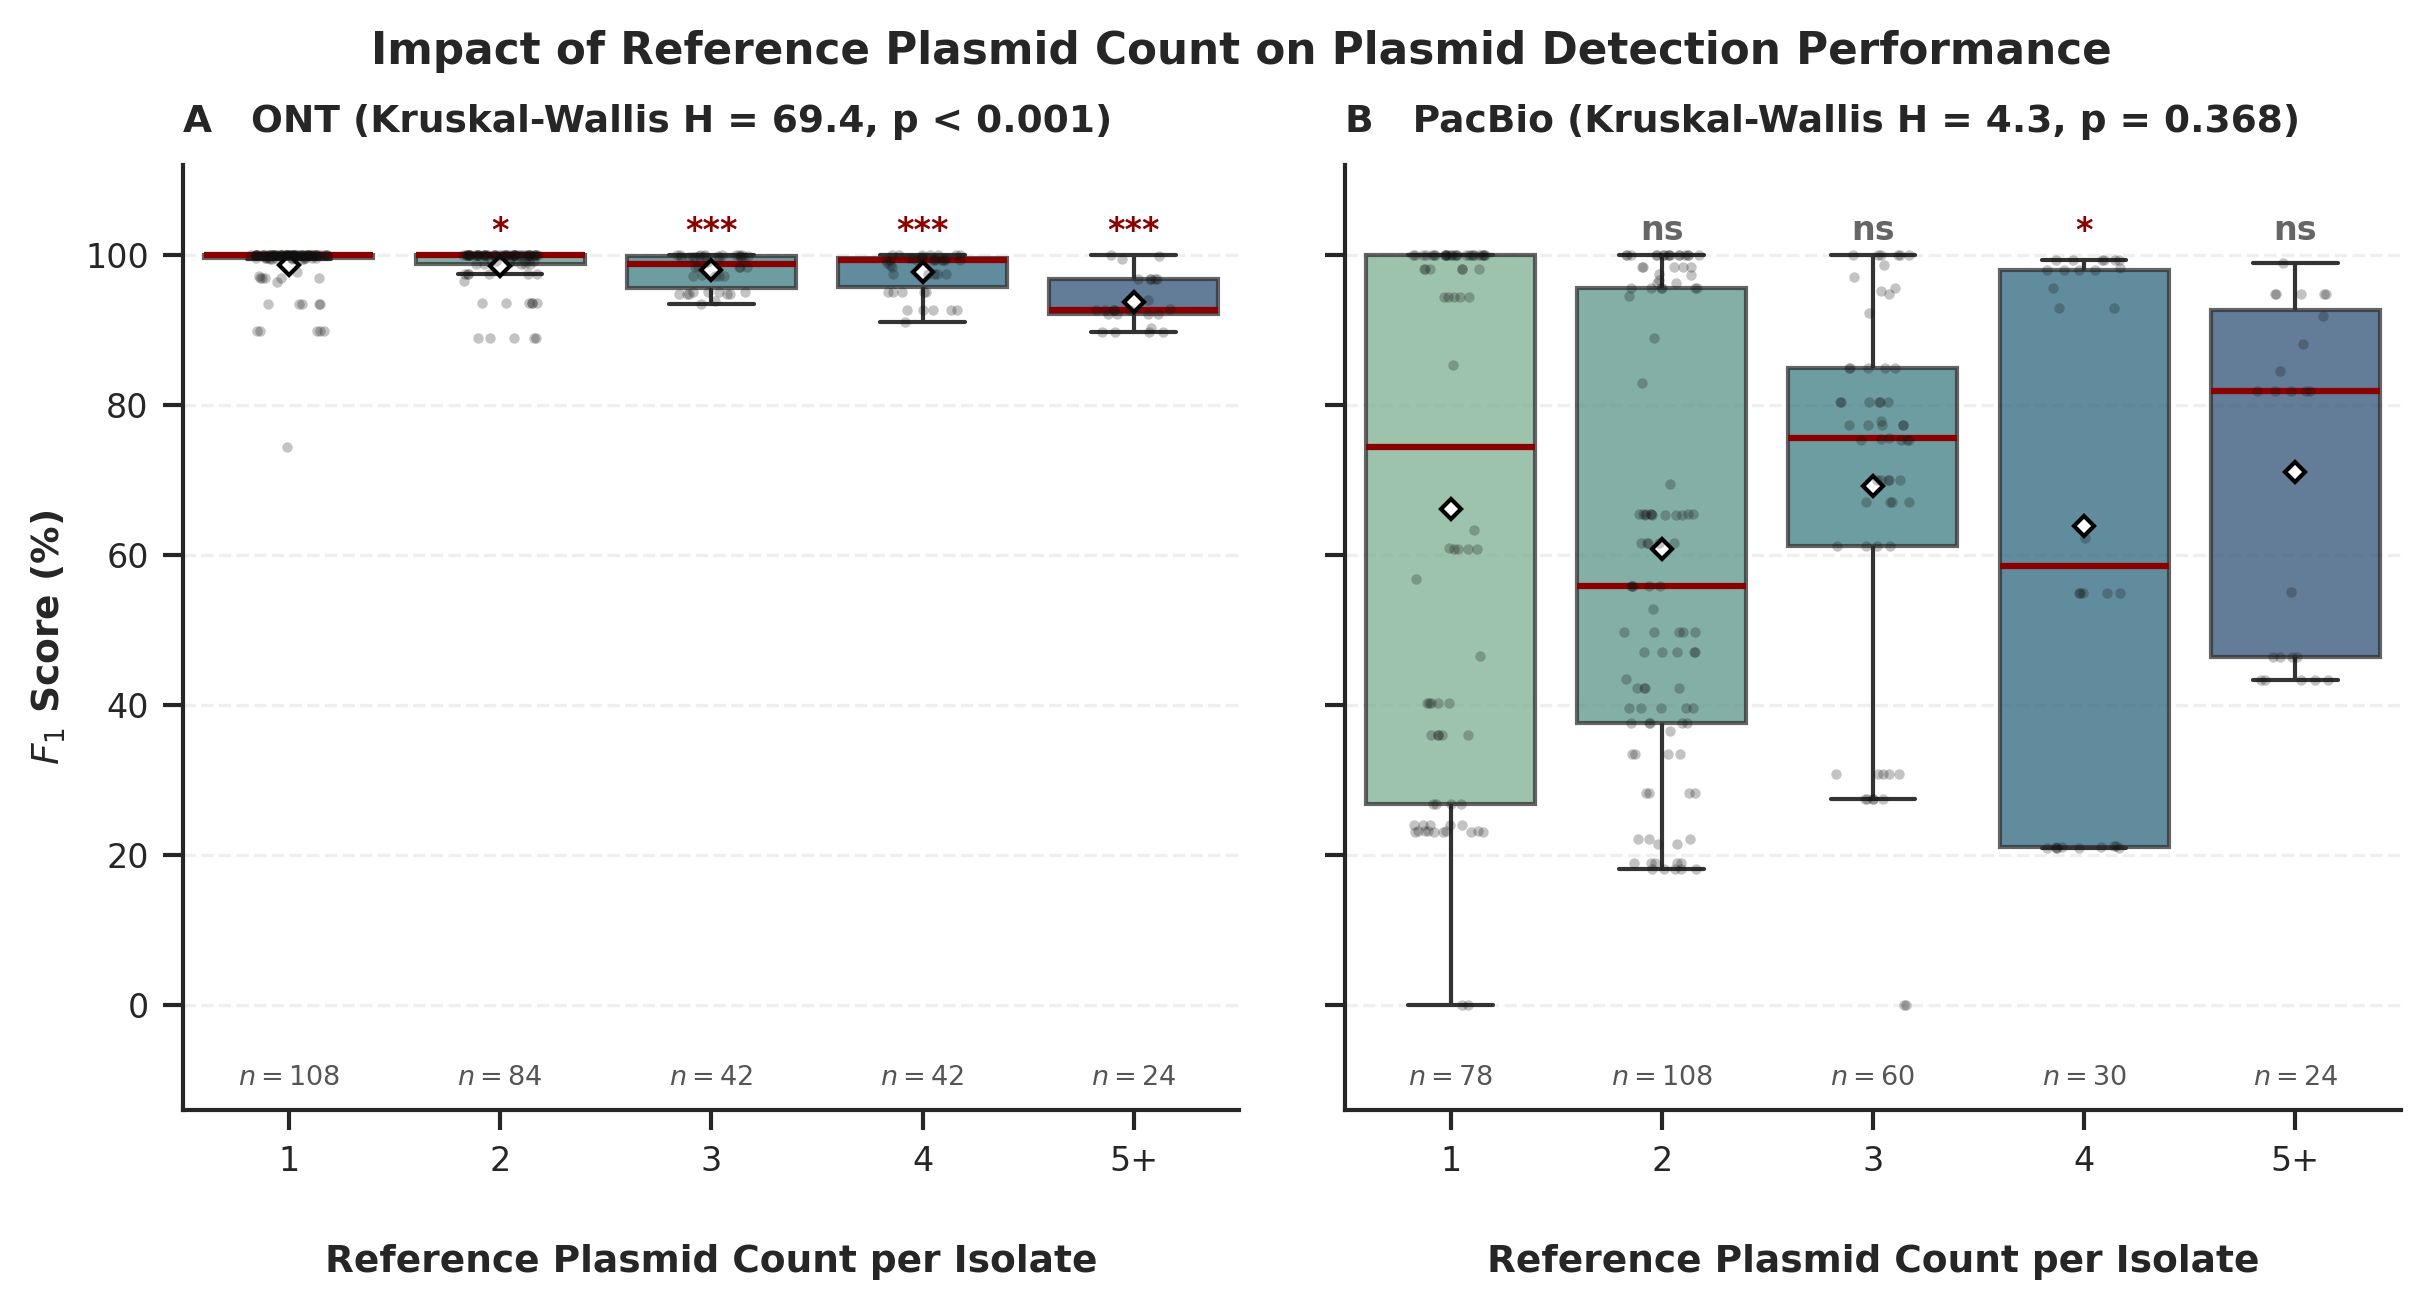

In [25]:
# --- Figure 12: Reference plasmid burden vs F1 ------------

# Configure publication-grade styling
plt.rcParams.update(
    {
        "font.family": "sans-serif",
        "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
        "font.size": 8,
        "axes.labelsize": 9,
        "axes.titlesize": 9.5,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# 1. Data Cleaning & Preparation
burden = df[["Tool", "Platform", "Ref_Plasmid_Count", "F1_Score"]].dropna().copy()
burden["Ref_Plasmid_Count"] = burden["Ref_Plasmid_Count"].astype(int)
burden["F1_pct"] = burden["F1_Score"] * 100.0

# Cap plasmid burden counts
BURDEN_CAP = 5
burden["Plasmid_Burden"] = burden["Ref_Plasmid_Count"].clip(upper=BURDEN_CAP)
burden["Plasmid_Burden_Label"] = burden["Plasmid_Burden"].astype(str)
burden.loc[
    burden["Ref_Plasmid_Count"] >= BURDEN_CAP, "Plasmid_Burden_Label"
] = f"{BURDEN_CAP}+"

burden_order = [
    str(x)
    for x in sorted(
        burden.loc[
            burden["Ref_Plasmid_Count"] < BURDEN_CAP, "Ref_Plasmid_Count"
        ].unique()
    )
]
if (burden["Ref_Plasmid_Count"] >= BURDEN_CAP).any():
    burden_order.append(f"{BURDEN_CAP}+")

n_platforms = len(PLATFORMS)
fig, axes = plt.subplots(
    1,
    n_platforms,
    figsize=(4.2 * max(n_platforms, 1), 4.5),
    squeeze=False,
    sharey=True,
    dpi=300,
)

fig.suptitle(
    "Impact of Reference Plasmid Count on Plasmid Detection Performance",
    fontsize=10.5,
    fontweight="bold",
    y=0.98,
)

panel_tags = ["A", "B"]
burden_stats = []

# Helper function to convert p-values to standard significance stars
def get_p_asterisks(p_val):
    if p_val < 0.001:
        return "***"
    elif p_val < 0.01:
        return "**"
    elif p_val < 0.05:
        return "*"
    return "ns"

for idx, (ax, platform) in enumerate(zip(axes[0], PLATFORMS)):
    sub = burden[burden["Platform"] == platform].copy()

    # Draw Boxplot
    sns.boxplot(
        data=sub,
        x="Plasmid_Burden_Label",
        y="F1_pct",
        order=burden_order,
        showfliers=False,
        palette="crest",
        boxprops=dict(alpha=0.75, linewidth=1.0),
        whiskerprops=dict(linewidth=1.0, color="#333333"),
        capprops=dict(linewidth=1.0, color="#333333"),
        medianprops=dict(linewidth=1.5, color="#8b0000"),
        showmeans=True,
        meanprops=dict(
            marker="D",
            markeredgecolor="black",
            markerfacecolor="white",
            markersize=3.5,
        ),
        ax=ax,
    )

    # Overlay Strip Plot Jitter
    sns.stripplot(
        data=sub,
        x="Plasmid_Burden_Label",
        y="F1_pct",
        order=burden_order,
        color="#111111",
        alpha=0.25,
        size=2.5,
        jitter=0.18,
        ax=ax,
    )

    # 2. Sample Size Annotations (n=...) below 0% Line
    group_counts = sub.groupby("Plasmid_Burden_Label")["F1_pct"].count()
    for cat_idx, label in enumerate(burden_order):
        n_val = group_counts.get(label, 0)
        ax.text(
            cat_idx,
            -8.0,
            f"$n={n_val}$",
            ha="center",
            va="top",
            fontsize=6.5,
            color="#555555",
        )

    # 3. Pairwise Statistical Significance Testing vs. Baseline (Group "1")
    baseline_vals = sub[sub["Plasmid_Burden_Label"] == "1"]["F1_pct"].dropna().values

    for cat_idx, label in enumerate(burden_order):
        # Baseline group doesn't compare against itself
        if label == "1":
            continue

        comp_vals = sub[sub["Plasmid_Burden_Label"] == label]["F1_pct"].dropna().values

        if len(baseline_vals) >= 3 and len(comp_vals) >= 3:
            # Mann-Whitney U Test
            _, p_val = stats.mannwhitneyu(
                baseline_vals, comp_vals, alternative="two-sided"
            )
            stars = get_p_asterisks(p_val)

            # Find maximum whisker/point height to place stars cleanly above data
            y_max = comp_vals.max() if len(comp_vals) > 0 else 100.0
            annotation_y = min(101.0, y_max + 3.0)

            ax.text(
                cat_idx,
                annotation_y,
                stars,
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold",
                color="#8b0000" if stars != "ns" else "#666666",
            )

    # 4. Kruskal-Wallis Global Test & Dynamic Header Construction
    groups = [
        sub[sub["Plasmid_Burden_Label"] == g]["F1_pct"].dropna().values
        for g in burden_order
    ]
    groups = [g for g in groups if len(g) >= 3]

    if len(groups) >= 2:
        h_stat, p_val = stats.kruskal(*groups)
        burden_stats.append({"Platform": platform, "H": h_stat, "p_value": p_val})

        p_str = "p < 0.001" if p_val < 0.001 else f"p = {p_val:.3f}"
        stat_title = f"{panel_tags[idx]}   {platform} (Kruskal-Wallis H = {h_stat:.1f}, {p_str})"
    else:
        stat_title = f"{panel_tags[idx]}   {platform} Platform"

    ax.set_title(
        stat_title,
        loc="left",
        fontweight="bold",
        fontsize=9,
        pad=8,
    )

    # Labeling & Axes
    ax.set_xlabel("Reference Plasmid Count per Isolate", fontweight="bold", labelpad=16)

    if idx == 0:
        ax.set_ylabel("$F_1$ Score (%)", fontweight="bold")
    else:
        ax.set_ylabel("")

    # Canvas boundaries
    ax.set_ylim(-14, 112)
    ax.grid(axis="y", alpha=0.3, linestyle="--", color="#cccccc")
    sns.despine(ax=ax, top=True, right=True)

plt.subplots_adjust(left=0.08, right=0.96, top=0.88, bottom=0.18, wspace=0.10)

# Save High-DPI Publication Outputs
plt.savefig(
    f"{OUTPUT_DIR}/fig12_ecoli_plasmid_burden_vs_f1_journal.png",
    dpi=300,
    bbox_inches="tight",
)
plt.savefig(
    f"{OUTPUT_DIR}/fig12_ecoli_plasmid_burden_vs_f1_journal.pdf",
    bbox_inches="tight",
)
plt.show()

# Save Kruskal-Wallis summary table
if burden_stats:
    burden_stats_df = pd.DataFrame(burden_stats)
    burden_stats_df.to_csv(
        f"{OUTPUT_DIR}/table12_plasmid_burden_kruskal_ecoli.tsv",
        sep="\t",
        index=False,
    )


In [26]:
# --- Summary ---------------------------------
print()
print("=" * 60)
print(" Statistical Analysis Complete")
print("=" * 60)
print(f"Output : {OUTPUT_DIR}")
print()
print("Files generated:")
for f in sorted(Path(OUTPUT_DIR).glob("*")):
    print(f"  {f.name}")



 Statistical Analysis Complete
Output : results/statistical_analysis

Files generated:
  descriptive_statistics.tsv
  fig10_ecoli_completeness_contamination_clean.pdf
  fig10_ecoli_completeness_contamination_clean.png
  fig11_ecoli_tool_rank_heatmap.pdf
  fig11_ecoli_tool_rank_heatmap.png
  fig12_ecoli_plasmid_burden_vs_f1_journal.pdf
  fig12_ecoli_plasmid_burden_vs_f1_journal.png
  fig1_overall_performance.pdf
  fig1_overall_performance.png
  fig1_overall_performance_ecdf.pdf
  fig1_overall_performance_ecdf.png
  fig2_platform_comparison.pdf
  fig2_platform_comparison.png
  fig3_size_stratified.pdf
  fig3_size_stratified.png
  fig4_posthoc_pairwise_journal.pdf
  fig4_posthoc_pairwise_journal.png
  fig5_benchmark_6panel_ecoli_journal.pdf
  fig5_benchmark_6panel_ecoli_journal.png
  fig6_size_dependence_ecoli_circularization.pdf
  fig6_size_dependence_ecoli_circularization.png
  fig6_size_dependence_ecoli_contamination.pdf
  fig6_size_dependence_ecoli_contamination.png
  fig6_size_depen

In [27]:
import scipy
import scikit_posthocs
import statsmodels

print(scipy.__version__)
print(scikit_posthocs.__version__)
print(statsmodels.__version__)


1.12.0
0.13.0
0.14.2
